# Task 3 — Fashion Occasion and Gender Classification

**COSC2753 Assignment 2** · Neural network approach

Given a fashion-item image, predict **who the item is intended for** (`gender`) and **what
occasion it suits** (`usage`).

## Problem framing

The specification allows gender and usage to be modelled as two separate targets or as one
combined class. This notebook uses a **multi-task convolutional neural network**: a single
shared convolutional backbone with two independent classification heads.

The justification is threefold:

1. **Shared visual features.** The cues that identify a garment as menswear (cut, colour
   palette, silhouette) largely overlap with the cues that identify it as formal or sporty.
   A shared backbone learns those features once from twice the supervisory signal.
2. **Avoids label sparsity.** A single combined class would produce 27 observed
   `gender x usage` combinations, many with fewer than 20 examples, and would make the model
   unable to predict combinations absent from training.
3. **Deployment cost.** One forward pass produces both predictions, which halves inference
   cost relative to two independent models — relevant to the application component of the
   assignment.

Single-task baselines are trained later in the notebook so this choice is supported by
evidence rather than assertion.

## Evaluation strategy

* **Grouped, stratified hold-out** (train / validation / test) for architecture and
  hyper-parameter search. Grouping is by product name because the dataset contains many
  near-identical photographs of the same product; an ungrouped split leaks them across
  partitions and inflates the score.
* **5-fold grouped cross-validation** on the winning configuration only, to quantify the
  variance of the estimate without paying 5x the cost for every experiment.
* **Macro-F1 as the primary metric.** `usage` is 76.9% `Casual`, so plain accuracy is
  misleading — a constant predictor already reaches that figure.

## Regularisation ("pruning")

For neural networks the analogues of pre- and post-pruning are:

* **Pre-pruning** — capacity is constrained *during* training: early stopping on validation
  macro-F1, dropout, weight decay, and batch normalisation.
* **Post-pruning** — the trained network is *reduced after* convergence: global magnitude
  (L1-unstructured) weight pruning followed by fine-tuning, evaluated across sparsity levels.

Both are implemented and measured below.

## 1. Setup, configuration and reproducibility

In [2]:
# ============================================
# CELL 1 - Imports, device and global configuration
# ============================================

import os
import json
import time
import copy
import random
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from PIL import Image

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)

RANDOM_STATE = 42


def set_seed(seed=RANDOM_STATE):
    """Seed every source of randomness we rely on."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("Device :", DEVICE)
if DEVICE.type == "cuda":
    print("GPU    :", torch.cuda.get_device_name(0))
    print("VRAM   :", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2), "GB")
    # cuDNN autotuner: input size is fixed, so this is a free speed-up
    torch.backends.cudnn.benchmark = True

PyTorch: 2.11.0+cu128
Device : cuda
GPU    : NVIDIA GeForce RTX 3060 Laptop GPU
VRAM   : 6.44 GB


In [3]:
# ============================================
# CELL 2 - Paths (mirrors 01_eda.ipynb)
# ============================================

NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = NOTEBOOK_DIR.parent

DATASET_ROOT = PROJECT_DIR / "A2_FashionDataset"
DATASET_DIR = DATASET_ROOT / "FashionDataset"

TRAIN_DIR = DATASET_DIR / "train"
TEST_DIR = DATASET_DIR / "test"

TRAIN_IMAGE_DIR = TRAIN_DIR / "images_train"
TEST_IMAGE_DIR = TEST_DIR / "images_test"

PROCESSED_DIR = DATASET_ROOT / "processed"
ARTIFACT_DIR = PROJECT_DIR / "artifacts" / "task3"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

CLEAN_METADATA = PROCESSED_DIR / "clean_train_metadata.csv"
PREDICTION_METADATA = PROCESSED_DIR / "prediction_metadata.csv"

assert CLEAN_METADATA.exists(), (
    f"Cannot find {CLEAN_METADATA}. Run 01_eda.ipynb first - it produces this file."
)

print("Processed directory:", PROCESSED_DIR)
print("Artifact directory :", ARTIFACT_DIR)

Processed directory: c:\Users\LEGION\Documents\jupyter_notebook\Fashion-Intelligence-System\A2_FashionDataset\processed
Artifact directory : c:\Users\LEGION\Documents\jupyter_notebook\Fashion-Intelligence-System\artifacts\task3


In [4]:
# ============================================
# CELL 3 - Experiment configuration
# ============================================

# Defaults below come from the EVIDENCE of the first full run, preserved in
# 04_task3_gender_usage_RUN1_backup.ipynb. Three findings drove the changes:
#   1. Heavy augmentation cost ~11 macro-F1 points. These are standardised
#      catalogue photos (centred product, white background), so rotation,
#      colour jitter and erasing create images unlike anything seen at test time.
#   2. Class weights changed nothing (74.82 -> 74.60, inside the +-2.13 CV noise)
#      but inverted probability calibration, making the confidence thresholds
#      used by the application meaningless.
#   3. Collapsing the four rare usage classes into 'Other' produced a class with
#      F1 = 0.000, costing roughly 15 macro-F1 points for no benefit.

CONFIG = {
    # --- image ---
    "image_width": 60,
    "image_height": 80,
    "channels": 3,

    # --- targets ---
    "targets": ["gender", "usage"],
    "rare_strategy": "drop",      # RUN 1: 'group' created a dead 'Other' class
    "min_class_size": 100,

    # --- splitting ---
    "test_fraction": 0.15,
    "val_fraction": 0.15,
    "group_column": "productDisplayName",

    # --- training ---
    "batch_size": 128,
    "max_epochs": 60,
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "early_stopping_patience": 8,    # pre-pruning
    "lr_patience": 4,
    "grad_clip": 5.0,
    "use_amp": True,
    "task_weights": {"gender": 1.0, "usage": 1.0},
    "use_class_weights": False,      # RUN 1: no gain, and it breaks calibration

    # --- augmentation ---
    # "none"   -> best in RUN 1
    # "gentle" -> horizontal flip only, safe for centred catalogue photography
    # "heavy"  -> full affine/jitter/erasing pipeline (RUN 1: -11 macro-F1)
    "augmentation": "none",

    # --- dataloader ---
    # Keep at 0 on Windows: Jupyter uses 'spawn' and worker processes cannot
    # pickle classes defined inside a notebook, which hangs the kernel.
    "num_workers": 0,

    # --- budget (lower = faster; raise for the final reported run) ---
    "ablation_max_epochs": 25,
    "search_budget": 4,
    "cv_folds": 3,
}

IMAGE_SIZE_PIL = (CONFIG["image_width"], CONFIG["image_height"])
IMAGE_SHAPE = (CONFIG["image_height"], CONFIG["image_width"], 3)

print(json.dumps(CONFIG, indent=2))

{
  "image_width": 60,
  "image_height": 80,
  "channels": 3,
  "targets": [
    "gender",
    "usage"
  ],
  "rare_strategy": "drop",
  "min_class_size": 100,
  "test_fraction": 0.15,
  "val_fraction": 0.15,
  "group_column": "productDisplayName",
  "batch_size": 128,
  "max_epochs": 60,
  "learning_rate": 0.001,
  "weight_decay": 0.0001,
  "early_stopping_patience": 8,
  "lr_patience": 4,
  "grad_clip": 5.0,
  "use_amp": true,
  "task_weights": {
    "gender": 1.0,
    "usage": 1.0
  },
  "use_class_weights": false,
  "augmentation": "none",
  "num_workers": 0,
  "ablation_max_epochs": 25,
  "search_budget": 4,
  "cv_folds": 3
}


## 2. Load the cleaned metadata

The notebook consumes `clean_train_metadata.csv` produced by `01_eda.ipynb`, which has already
had the CSV parsing artefacts repaired and rows without images removed. Nothing is re-derived
here, so both notebooks cannot drift apart.

In [5]:
# ============================================
# CELL 4 - Load metadata and recap the two targets
# ============================================

data = pd.read_csv(CLEAN_METADATA)
print("Rows:", len(data), "| Columns:", list(data.columns))

for target in CONFIG["targets"]:
    print("\n" + "=" * 55)
    print(target.upper(), "-", data[target].nunique(), "classes,",
          int(data[target].isna().sum()), "missing")
    print("=" * 55)
    summary = pd.DataFrame({
        "Count": data[target].value_counts(dropna=False),
        "Percent": (data[target].value_counts(dropna=False, normalize=True) * 100).round(2),
    })
    display(summary)

Rows: 38612 | Columns: ['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName', 'image_path']

GENDER - 5 classes, 0 missing


,Count,Percent
gender,,
Men,20913,54.16
Women,14160,36.67
Unisex,2080,5.39
Boys,814,2.11
Girls,645,1.67



USAGE - 8 classes, 72 missing


,Count,Percent
usage,,
Casual,29636,76.75
Sports,3940,10.20
Ethnic,2570,6.66
Formal,2300,5.96
NaN,72,0.19
Smart Casual,55,0.14
Travel,25,0.06
Party,13,0.03
Home,1,0.00


usage,Casual,Ethnic,Formal,Home,Party,Smart Casual,Sports,Travel,NaN
gender,,,,,,,,,
Boys,783,10,0,0,0,0,21,0,0
Girls,635,8,0,0,0,0,2,0,0
Men,15686,90,2193,0,0,44,2876,1,23
Unisex,1758,0,1,1,0,0,282,20,18
Women,10774,2462,106,0,13,11,759,4,31


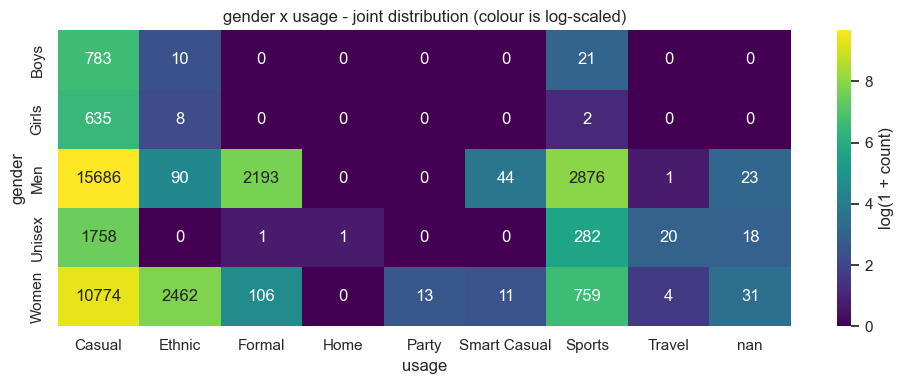

Observed gender x usage combinations: 27 of 45 possible
Combinations with fewer than 20 examples: 10


In [6]:
# ============================================
# CELL 5 - Joint distribution of the two targets
# ============================================

joint = pd.crosstab(data["gender"], data["usage"], dropna=False)
display(joint)

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(np.log1p(joint), annot=joint.values, fmt="d", cmap="viridis", ax=ax,
            cbar_kws={"label": "log(1 + count)"})
ax.set_title("gender x usage - joint distribution (colour is log-scaled)")
plt.tight_layout()
plt.show()

print("Observed gender x usage combinations:",
      int((joint.values > 0).sum()), "of", joint.size, "possible")
print("Combinations with fewer than 20 examples:",
      int(((joint.values > 0) & (joint.values < 20)).sum()))

The joint table is the evidence for the modelling choice stated at the top: of the possible
`gender x usage` combinations only a minority are observed, and many of those are extremely
sparse. A single combined target would therefore spend most of its capacity on classes it can
never learn, whereas two heads share the dense marginal signal.

## 3. Target preparation

Two issues must be resolved before encoding.

**Missing `usage` labels (72 rows).** These are dropped rather than imputed. Imputing the
majority class would inject 72 confidently wrong labels into the most over-represented class,
which is precisely the class the model is already biased towards. The loss is 0.19% of the data.

**Rare `usage` classes.** `Home` (1), `Party` (13), `Travel` (25) and `Smart Casual` (55) are
far too small to learn or to stratify. They are collapsed into a single `Other` class so the
information is retained and the model can express "none of the four main occasions", rather
than being deleted. `CONFIG["rare_strategy"] = "drop"` switches to the alternative for
comparison in the report.

In [7]:
# ============================================
# CELL 6 - Resolve missing and rare target labels
# ============================================

model_df = data.copy()
n_start = len(model_df)

# 1) rows with no usage label cannot supervise the usage head
missing_usage = model_df["usage"].isna().sum()
model_df = model_df[model_df["usage"].notna()].copy()
print(f"Dropped {missing_usage} rows with a missing `usage` label "
      f"({missing_usage / n_start * 100:.2f}%)")

# gender has no missing values in this dataset, but do not assume it
missing_gender = model_df["gender"].isna().sum()
if missing_gender:
    model_df = model_df[model_df["gender"].notna()].copy()
    print(f"Dropped {missing_gender} rows with a missing `gender` label")

# 2) rare classes
for target in CONFIG["targets"]:
    counts = model_df[target].value_counts()
    rare = counts[counts < CONFIG["min_class_size"]].index.tolist()

    if not len(rare):
        model_df[target + "_label"] = model_df[target]
        print(f"`{target}`: no class below {CONFIG['min_class_size']} - unchanged "
              f"({model_df[target].nunique()} classes)")
        continue

    affected = int(counts[rare].sum())
    if CONFIG["rare_strategy"] == "group":
        model_df[target + "_label"] = model_df[target].where(
            ~model_df[target].isin(rare), "Other")
        print(f"`{target}`: collapsed {len(rare)} rare classes {rare} "
              f"({affected} rows) into 'Other'")
    else:
        model_df = model_df[~model_df[target].isin(rare)].copy()
        model_df[target + "_label"] = model_df[target]
        print(f"`{target}`: dropped {len(rare)} rare classes {rare} ({affected} rows)")

print(f"\nRows: {n_start} -> {len(model_df)}")
for target in CONFIG["targets"]:
    display(model_df[target + "_label"].value_counts().to_frame("Count"))

Dropped 72 rows with a missing `usage` label (0.19%)
`gender`: no class below 100 - unchanged (5 classes)
`usage`: dropped 4 rare classes ['Smart Casual', 'Travel', 'Party', 'Home'] (94 rows)

Rows: 38612 -> 38446


,Count
gender_label,
Men,20845
Women,14101
Unisex,2041
Boys,814
Girls,645


,Count
usage_label,
Casual,29636
Sports,3940
Ethnic,2570
Formal,2300


In [8]:
# ============================================
# CELL 7 - Encode the labels
# ============================================

from sklearn.preprocessing import LabelEncoder

encoders = {}
class_names = {}

for target in CONFIG["targets"]:
    encoder = LabelEncoder()
    model_df[target + "_y"] = encoder.fit_transform(model_df[target + "_label"].astype(str))
    encoders[target] = encoder
    class_names[target] = list(encoder.classes_)
    print(f"{target:8s} -> {len(encoder.classes_)} classes: {list(encoder.classes_)}")

NUM_CLASSES = {t: len(encoders[t].classes_) for t in CONFIG["targets"]}

# Persist immediately - predictions cannot be decoded without these
with open(ARTIFACT_DIR / "label_classes.json", "w") as f:
    json.dump(class_names, f, indent=2)
print("\nSaved", ARTIFACT_DIR / "label_classes.json")

gender   -> 5 classes: ['Boys', 'Girls', 'Men', 'Unisex', 'Women']
usage    -> 4 classes: ['Casual', 'Ethnic', 'Formal', 'Sports']

Saved c:\Users\LEGION\Documents\jupyter_notebook\Fashion-Intelligence-System\artifacts\task3\label_classes.json


## 4. Baselines

Before any model is trained, the numbers it must beat are established. Two references are used:

* **Majority-class** — always predict the most frequent class. This is the honest floor.
* **Stratified random** — sample predictions from the training distribution. This shows what
  macro-F1 looks like for a model that has learned nothing but the priors.

Reporting accuracy alone would be actively misleading for `usage`, where the majority class is
roughly 77% of the data.

In [9]:
# ============================================
# CELL 8 - Majority-class and random baselines
# ============================================

from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score

baseline_rows = []
X_dummy = np.zeros((len(model_df), 1))

for target in CONFIG["targets"]:
    y = model_df[target + "_y"].values
    for strategy in ["most_frequent", "stratified"]:
        dummy = DummyClassifier(strategy=strategy, random_state=RANDOM_STATE)
        dummy.fit(X_dummy, y)
        pred = dummy.predict(X_dummy)
        baseline_rows.append({
            "Target": target,
            "Baseline": strategy,
            "Accuracy": round(accuracy_score(y, pred) * 100, 2),
            "MacroF1": round(f1_score(y, pred, average="macro") * 100, 2),
            "BalancedAcc": round(balanced_accuracy_score(y, pred) * 100, 2),
        })

baseline_df = pd.DataFrame(baseline_rows)
display(baseline_df)

BASELINE = {
    t: baseline_df[(baseline_df["Target"] == t) &
                   (baseline_df["Baseline"] == "most_frequent")].iloc[0].to_dict()
    for t in CONFIG["targets"]
}
print("Targets to beat (majority class):")
for t, row in BASELINE.items():
    print(f"  {t:8s} accuracy {row['Accuracy']:.2f}%  macro-F1 {row['MacroF1']:.2f}%")

,Target,Baseline,Accuracy,MacroF1,BalancedAcc
0,gender,most_frequent,54.22,14.06,20.00
1,gender,stratified,43.14,20.12,20.12
2,usage,most_frequent,77.08,21.76,25.00
3,usage,stratified,61.40,24.95,24.95


Targets to beat (majority class):
  gender   accuracy 54.22%  macro-F1 14.06%
  usage    accuracy 77.08%  macro-F1 21.76%


## 5. Grouped, stratified train / validation / test split

Three constraints must hold simultaneously:

1. **No group leakage.** Rows sharing a `productDisplayName` are near-identical photographs and
   must stay together. The EDA found over 15,000 such rows.
2. **Stratification on both targets.** Stratifying on `gender` alone can starve a `usage` class,
   and vice versa. The split is therefore stratified on the *combined* `gender x usage` label,
   which preserves both marginals.
3. **A genuine held-out test set.** The provided `images_test` has no labels, so the reported
   test performance must come from data this notebook never trains or tunes on.

In [10]:
# ============================================
# CELL 9 - Three-way grouped stratified split
# ============================================

from sklearn.model_selection import StratifiedGroupKFold

# stratification key combines both targets so neither marginal is distorted
model_df["_strat"] = (
    model_df["gender_label"].astype(str) + "|" + model_df["usage_label"].astype(str)
)

# combinations too small to stratify are pooled into a catch-all key
strat_counts = model_df["_strat"].value_counts()
tiny = strat_counts[strat_counts < 10].index
model_df.loc[model_df["_strat"].isin(tiny), "_strat"] = "RARE_COMBO"
print("Stratification keys:", model_df["_strat"].nunique(),
      f"(pooled {len(tiny)} combinations with <10 rows)")

groups = model_df[CONFIG["group_column"]].fillna(model_df["id"].astype(str))


def grouped_split(df, strat, grp, fraction, seed):
    """Hold out approximately `fraction` of rows, grouped and stratified."""
    n_splits = max(2, int(round(1 / fraction)))
    splitter = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    keep_idx, hold_idx = next(splitter.split(df, strat, grp))
    return df.iloc[keep_idx], df.iloc[hold_idx]


# test split first, so it is untouched by everything that follows
trainval_df, test_df = grouped_split(
    model_df, model_df["_strat"], groups, CONFIG["test_fraction"], RANDOM_STATE
)

# then carve validation out of the remainder
tv_groups = trainval_df[CONFIG["group_column"]].fillna(trainval_df["id"].astype(str))
val_fraction_adj = CONFIG["val_fraction"] / (1 - CONFIG["test_fraction"])
train_df, val_df = grouped_split(
    trainval_df, trainval_df["_strat"], tv_groups, val_fraction_adj, RANDOM_STATE
)

for name, part in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"{name:6s} {len(part):>6d} rows  ({len(part) / len(model_df) * 100:.1f}%)")

Stratification keys: 15 (pooled 3 combinations with <10 rows)
train   27460 rows  (71.4%)
val      5493 rows  (14.3%)
test     5493 rows  (14.3%)


In [11]:
# ============================================
# CELL 10 - Verify the split (leakage and stratification)
# ============================================

g_train = set(train_df[CONFIG["group_column"]].fillna(train_df["id"].astype(str)))
g_val = set(val_df[CONFIG["group_column"]].fillna(val_df["id"].astype(str)))
g_test = set(test_df[CONFIG["group_column"]].fillna(test_df["id"].astype(str)))

print("Group overlap train/val :", len(g_train & g_val))
print("Group overlap train/test:", len(g_train & g_test))
print("Group overlap val/test  :", len(g_val & g_test))
assert not (g_train & g_val), "Leakage between train and validation"
assert not (g_train & g_test), "Leakage between train and test"
assert not (g_val & g_test), "Leakage between validation and test"

# id-level check as a belt-and-braces guard
assert not (set(train_df["id"]) & set(val_df["id"]))
assert not (set(train_df["id"]) & set(test_df["id"]))
assert not (set(val_df["id"]) & set(test_df["id"]))

for target in CONFIG["targets"]:
    comparison = pd.DataFrame({
        "train %": train_df[target + "_label"].value_counts(normalize=True) * 100,
        "val %": val_df[target + "_label"].value_counts(normalize=True) * 100,
        "test %": test_df[target + "_label"].value_counts(normalize=True) * 100,
    }).round(2)
    print(f"\nClass distribution across splits - {target}")
    display(comparison)

    # every class must appear in every split, otherwise metrics are undefined
    for split_name, part in [("val", val_df), ("test", test_df)]:
        missing = set(train_df[target + "_label"]) - set(part[target + "_label"])
        if missing:
            print(f"  WARNING: classes absent from {split_name}: {missing}")

Group overlap train/val : 0
Group overlap train/test: 0
Group overlap val/test  : 0

Class distribution across splits - gender


,train %,val %,test %
gender_label,,,
Men,54.22,54.21,54.21
Women,36.68,36.66,36.70
Unisex,5.31,5.32,5.32
Boys,2.12,2.11,2.11
Girls,1.68,1.69,1.66



Class distribution across splits - usage


,train %,val %,test %
usage_label,,,
Casual,77.08,77.08,77.10
Sports,10.24,10.27,10.25
Ethnic,6.69,6.68,6.68
Formal,5.99,5.97,5.97


## 6. Image pipeline

Decoding ~38,000 JPEGs on every epoch is the dominant cost on a GPU — the accelerator would sit
idle waiting for the CPU. The images are therefore decoded **once** into a `uint8` memory-mapped
array (~556 MB at 60x80x3) and indexed directly thereafter. This also removes the need for
DataLoader worker processes, which are unreliable inside Jupyter on Windows.

Every image is converted to RGB (the EDA found 343 greyscale files) and explicitly resized (17
files are not at the modal resolution).

In [12]:
# ============================================
# CELL 11 - Build (or load) the uint8 image cache
# ============================================

CACHE_X = PROCESSED_DIR / f"image_cache_{CONFIG['image_width']}x{CONFIG['image_height']}.npy"
CACHE_IDS = PROCESSED_DIR / f"image_cache_{CONFIG['image_width']}x{CONFIG['image_height']}_ids.npy"


def load_image_array(path, size=IMAGE_SIZE_PIL):
    """Single source of truth for reading one image (train and test alike)."""
    with Image.open(path) as img:
        img = img.convert("RGB").resize(size, Image.BILINEAR)
        return np.asarray(img, dtype=np.uint8)


all_ids = model_df["id"].to_numpy()

if CACHE_X.exists() and CACHE_IDS.exists():
    cached_ids = np.load(CACHE_IDS)
    if len(cached_ids) == len(all_ids) and (cached_ids == all_ids).all():
        IMAGES = np.load(CACHE_X, mmap_mode="r")
        print("Loaded image cache:", IMAGES.shape, IMAGES.dtype)
    else:
        print("Cache does not match the current row selection - rebuilding")
        CACHE_X.unlink(missing_ok=True)

if not CACHE_X.exists():
    print(f"Building cache for {len(model_df)} images ...")
    IMAGES = np.lib.format.open_memmap(
        CACHE_X, mode="w+", dtype=np.uint8, shape=(len(model_df),) + IMAGE_SHAPE
    )
    start = time.time()
    for position, path in enumerate(model_df["image_path"]):
        IMAGES[position] = load_image_array(path)
        if (position + 1) % 5000 == 0:
            print(f"  {position + 1}/{len(model_df)} ({time.time() - start:.0f}s)")
    IMAGES.flush()
    np.save(CACHE_IDS, all_ids)
    print(f"Cache built in {time.time() - start:.0f}s ->", CACHE_X)

# position in IMAGES for each dataframe row - the two must never drift apart
id_to_position = {image_id: position for position, image_id in enumerate(all_ids)}
for part in (train_df, val_df, test_df):
    part["cache_position"] = part["id"].map(id_to_position).astype(int)

# alignment check on a random row
probe = train_df.sample(1, random_state=RANDOM_STATE).iloc[0]
assert np.array_equal(
    np.asarray(IMAGES[probe["cache_position"]]), load_image_array(probe["image_path"])
), "Image cache is out of sync with the metadata"
print("Cache alignment verified.")

Cache does not match the current row selection - rebuilding
Building cache for 38446 images ...
  5000/38446 (3s)
  10000/38446 (6s)
  15000/38446 (9s)
  20000/38446 (12s)
  25000/38446 (14s)
  30000/38446 (18s)
  35000/38446 (21s)
Cache built in 23s -> c:\Users\LEGION\Documents\jupyter_notebook\Fashion-Intelligence-System\A2_FashionDataset\processed\image_cache_60x80.npy
Cache alignment verified.


In [13]:
# ============================================
# CELL 12 - Channel statistics from the TRAINING split only
# ============================================

# Computing normalisation statistics over the whole dataset would leak information
# from validation and test into training.
sample_positions = train_df["cache_position"].sample(
    min(4000, len(train_df)), random_state=RANDOM_STATE
).to_numpy()
sample_pixels = np.asarray(IMAGES[np.sort(sample_positions)], dtype=np.float32) / 255.0

CHANNEL_MEAN = sample_pixels.mean(axis=(0, 1, 2))
CHANNEL_STD = sample_pixels.std(axis=(0, 1, 2))

print("Channel mean:", CHANNEL_MEAN.round(4))
print("Channel std :", CHANNEL_STD.round(4))

del sample_pixels

Channel mean: [0.8549 0.8361 0.8268]
Channel std : [0.254  0.2594 0.2604]


In [14]:
# ============================================
# CELL 13 - Dataset and augmentation
# ============================================

from torchvision import transforms

_normalise = [
    transforms.ToTensor(),
    transforms.Normalize(CHANNEL_MEAN.tolist(), CHANNEL_STD.tolist()),
]

AUGMENTATIONS = {
    # No augmentation - strongest configuration in RUN 1.
    "none": transforms.Compose([transforms.ToPILImage()] + _normalise),

    # Horizontal flip only. Safe here because the photography is centred and
    # front-facing, so a mirrored garment is still a plausible catalogue image.
    "gentle": transforms.Compose(
        [transforms.ToPILImage(), transforms.RandomHorizontalFlip(p=0.5)] + _normalise
    ),

    # Full pipeline, retained so the ablation can demonstrate the harm.
    "heavy": transforms.Compose([
        transforms.ToPILImage(),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomAffine(degrees=10, translate=(0.06, 0.06), scale=(0.90, 1.10)),
        transforms.ColorJitter(brightness=0.20, contrast=0.20, saturation=0.20, hue=0.02),
        transforms.ToTensor(),
        transforms.Normalize(CHANNEL_MEAN.tolist(), CHANNEL_STD.tolist()),
        transforms.RandomErasing(p=0.25, scale=(0.02, 0.10)),
    ]),
}

eval_transform = AUGMENTATIONS["none"]
train_transform = AUGMENTATIONS[CONFIG["augmentation"]]


class FashionMultiTaskDataset(Dataset):
    """Serves (image, gender_label, usage_label) triples from the memmap cache."""

    def __init__(self, frame, images, transform):
        self.positions = frame["cache_position"].to_numpy()
        self.gender = frame["gender_y"].to_numpy()
        self.usage = frame["usage_y"].to_numpy()
        self.images = images
        self.transform = transform

    def __len__(self):
        return len(self.positions)

    def __getitem__(self, index):
        array = np.asarray(self.images[self.positions[index]])
        return self.transform(array), int(self.gender[index]), int(self.usage[index])


def make_loader(frame, train=False, batch_size=None, augmentation=None):
    """train=True shuffles; `augmentation` overrides CONFIG for ablation runs."""
    transform = (AUGMENTATIONS[augmentation or CONFIG["augmentation"]]
                 if train else eval_transform)
    return DataLoader(
        FashionMultiTaskDataset(frame, IMAGES, transform),
        batch_size=batch_size or CONFIG["batch_size"],
        shuffle=train,
        num_workers=CONFIG["num_workers"],
        pin_memory=(DEVICE.type == "cuda"),
        drop_last=False,
    )


train_loader = make_loader(train_df, train=True)
val_loader = make_loader(val_df)
test_loader = make_loader(test_df)

images_batch, gender_batch, usage_batch = next(iter(train_loader))
print("Augmentation :", CONFIG["augmentation"])
print("Batch        :", images_batch.shape, images_batch.dtype)
print("Classes      :", NUM_CLASSES)

Augmentation : none
Batch        : torch.Size([128, 3, 80, 60]) torch.float32
Classes      : {'gender': 5, 'usage': 4}


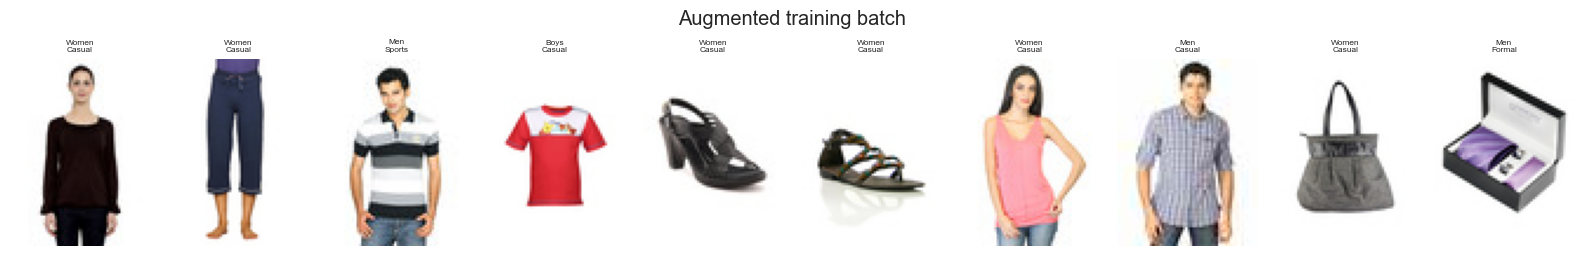

In [15]:
# ============================================
# CELL 14 - Inspect an augmented batch
# ============================================

denormalised = (
    images_batch[:10].permute(0, 2, 3, 1).numpy() * CHANNEL_STD + CHANNEL_MEAN
)

fig, axes = plt.subplots(1, 10, figsize=(16, 2.6))
for ax, image, g, u in zip(axes, denormalised, gender_batch[:10], usage_batch[:10]):
    ax.imshow(np.clip(image, 0, 1))
    ax.set_title(f"{class_names['gender'][g]}\n{class_names['usage'][u]}", fontsize=6)
    ax.axis("off")
plt.suptitle("Augmented training batch")
plt.tight_layout()
plt.show()

## 7. Class imbalance

`gender` ranges from 20,913 (`Men`) to 645 (`Girls`); `usage` is 77% `Casual`. Without
intervention the network minimises loss by predicting the majority class, which is exactly the
behaviour the baseline already achieves.

Inverse-frequency class weights are applied to each head's loss. Weights are computed on the
**training split only**, and are capped to avoid a single tiny class dominating the gradient.

In [16]:
# ============================================
# CELL 15 - Class weights per head
# ============================================

from sklearn.utils.class_weight import compute_class_weight

WEIGHT_CAP = 10.0
class_weights = {}

for target in CONFIG["targets"]:
    y_train = train_df[target + "_y"].to_numpy()
    present = np.unique(y_train)

    weights = np.ones(NUM_CLASSES[target], dtype=np.float32)
    computed = compute_class_weight("balanced", classes=present, y=y_train)
    weights[present] = computed
    weights = np.clip(weights, 0.0, WEIGHT_CAP)

    class_weights[target] = torch.tensor(weights, dtype=torch.float32, device=DEVICE)

    display(pd.DataFrame({
        "Class": class_names[target],
        "TrainCount": [int((y_train == i).sum()) for i in range(NUM_CLASSES[target])],
        "Weight": weights.round(3),
    }))

,Class,TrainCount,Weight
0,Boys,582,9.436
1,Girls,461,10.000
2,Men,14889,0.369
3,Unisex,1457,3.769
4,Women,10071,0.545


,Class,TrainCount,Weight
0,Casual,21167,0.324
1,Ethnic,1836,3.739
2,Formal,1644,4.176
3,Sports,2813,2.440


## 8. Model architecture

A convolutional network trained **from scratch** — the specification forbids pretrained weights
from outside the assignment data.

* **Shared backbone.** Four convolutional blocks (Conv-BN-ReLU x2 then max-pool), widening
  32 -> 64 -> 128 -> 256. Batch normalisation stabilises training at higher learning rates and
  contributes regularisation; the doubling width compensates for the shrinking spatial map.
* **Global average pooling** instead of flattening. This removes roughly 90% of the parameters
  a dense layer would add, which is the single most effective structural defence against
  overfitting on 27k training images.
* **Two heads.** Each head is `Dropout -> Linear -> ReLU -> Dropout -> Linear`, so the tasks
  share representation but keep independent decision boundaries.

An MLP is also defined, as a deliberately weaker baseline that ignores spatial structure. It
exists to demonstrate *why* convolution is the right inductive bias here, rather than asserting it.

In [17]:
# ============================================
# CELL 16 - Multi-task CNN and MLP baseline
# ============================================

class ConvBlock(nn.Module):
    """Conv-BN-ReLU x2 followed by max-pooling."""

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

    def forward(self, x):
        return self.block(x)


class MultiTaskCNN(nn.Module):
    def __init__(self, num_classes, widths=(32, 64, 128, 256), dropout=0.4, head_hidden=128):
        super().__init__()
        channels = 3
        blocks = []
        for width in widths:
            blocks.append(ConvBlock(channels, width))
            channels = width
        self.backbone = nn.Sequential(*blocks)
        self.pool = nn.AdaptiveAvgPool2d(1)          # global average pooling

        def make_head(n_out):
            return nn.Sequential(
                nn.Dropout(dropout),
                nn.Linear(channels, head_hidden),
                nn.ReLU(inplace=True),
                nn.Dropout(dropout),
                nn.Linear(head_hidden, n_out),
            )

        self.heads = nn.ModuleDict(
            {target: make_head(n) for target, n in num_classes.items()}
        )

    def forward(self, x):
        features = self.pool(self.backbone(x)).flatten(1)
        return {target: head(features) for target, head in self.heads.items()}


class MultiTaskMLP(nn.Module):
    """Fully connected baseline - discards spatial structure entirely."""

    def __init__(self, num_classes, hidden=(512, 256), dropout=0.4):
        super().__init__()
        in_features = IMAGE_SHAPE[0] * IMAGE_SHAPE[1] * IMAGE_SHAPE[2]
        layers, previous = [], in_features
        for size in hidden:
            layers += [nn.Linear(previous, size), nn.BatchNorm1d(size),
                       nn.ReLU(inplace=True), nn.Dropout(dropout)]
            previous = size
        self.body = nn.Sequential(*layers)
        self.heads = nn.ModuleDict(
            {target: nn.Linear(previous, n) for target, n in num_classes.items()}
        )

    def forward(self, x):
        features = self.body(x.flatten(1))
        return {target: head(features) for target, head in self.heads.items()}


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


for name, model in [("MultiTaskCNN", MultiTaskCNN(NUM_CLASSES)),
                    ("MultiTaskMLP", MultiTaskMLP(NUM_CLASSES))]:
    print(f"{name:14s} {count_parameters(model):>10,} trainable parameters")

print()
print(MultiTaskCNN(NUM_CLASSES))

MultiTaskCNN    1,240,169 trainable parameters
MultiTaskMLP    7,508,489 trainable parameters

MultiTaskCNN(
  (backbone): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
        (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64

## 9. Training and evaluation machinery

**Loss.** A weighted cross-entropy per head, combined as
`L = w_gender * L_gender + w_usage * L_usage`. Equal task weights are used by default and the
sensitivity of the result to that choice is tested later.

**Model selection metric.** The mean of the two heads' macro-F1 scores on validation. Macro-F1
weights every class equally, so improvements on `Girls` or `Formal` count as much as
improvements on `Men` or `Casual` — which is the behaviour the imbalance demands.

**Pre-pruning.** Training halts when validation macro-F1 has not improved for
`early_stopping_patience` epochs, and the best-scoring weights are restored rather than the
last ones. Learning rate is reduced on plateau. Together with dropout and weight decay this is
the neural-network analogue of pre-pruning: capacity is constrained while the model is built.

In [18]:
# ============================================
# CELL 17 - AMP helpers (version tolerant)
# ============================================

USE_AMP = bool(CONFIG["use_amp"]) and DEVICE.type == "cuda"

try:                                    # PyTorch >= 2.0 API
    from torch.amp import GradScaler as _GradScaler, autocast as _autocast

    def make_scaler():
        return _GradScaler("cuda", enabled=USE_AMP)

    def amp_autocast():
        return _autocast("cuda", enabled=USE_AMP)

except (ImportError, TypeError):        # older API
    from torch.cuda.amp import GradScaler as _GradScaler, autocast as _autocast

    def make_scaler():
        return _GradScaler(enabled=USE_AMP)

    def amp_autocast():
        return _autocast(enabled=USE_AMP)

print("Mixed precision enabled:", USE_AMP)

Mixed precision enabled: True


In [19]:
# ============================================
# CELL 18 - Metrics
# ============================================

from sklearn.metrics import (accuracy_score, f1_score, balanced_accuracy_score,
                             classification_report, confusion_matrix)


def compute_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred) * 100,
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0) * 100,
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0) * 100,
        "balanced_acc": balanced_accuracy_score(y_true, y_pred) * 100,
    }


def summarise(predictions):
    """Per-head metrics plus, when both heads exist, the joint 'both correct' rate."""
    present = [t for t in CONFIG["targets"] if t in predictions]
    result = {}
    for target in present:
        result[target] = compute_metrics(predictions[target]["true"],
                                         predictions[target]["pred"])

    if len(present) == 2:
        both_correct = (
            (predictions["gender"]["true"] == predictions["gender"]["pred"]) &
            (predictions["usage"]["true"] == predictions["usage"]["pred"])
        )
        result["joint"] = {"exact_match": both_correct.mean() * 100}
    else:
        result["joint"] = {"exact_match": np.nan}

    result["mean_macro_f1"] = float(np.mean([result[t]["macro_f1"] for t in present]))
    result["targets"] = present
    return result


def metrics_frame(summary, label=""):
    rows = []
    for target in summary.get("targets", CONFIG["targets"]):
        row = {"Model": label, "Target": target}
        row.update({k: round(v, 2) for k, v in summary[target].items()})
        rows.append(row)
    return pd.DataFrame(rows)

In [20]:
# ============================================
# CELL 19 - Prediction and training loops
# ============================================

@torch.no_grad()
def predict(model, loader):
    """Return true labels, predictions and probabilities for both heads."""
    model.eval()
    active = list(model.heads.keys())          # supports single-task models too
    store = {t: {"true": [], "pred": [], "prob": []} for t in active}

    for images, gender, usage in loader:
        images = images.to(DEVICE, non_blocking=True)
        with amp_autocast():
            outputs = model(images)
        truths = {"gender": gender, "usage": usage}
        for target in active:
            logits = outputs[target].float()
            store[target]["true"].append(truths[target].numpy())
            store[target]["pred"].append(logits.argmax(1).cpu().numpy())
            store[target]["prob"].append(F.softmax(logits, dim=1).cpu().numpy())

    return {t: {k: np.concatenate(v) for k, v in store[t].items()} for t in active}


def train_model(model, loader_train, loader_val, config=None, tag="model", verbose=True):
    """Train with early stopping on mean validation macro-F1. Returns (model, history)."""
    cfg = {**CONFIG, **(config or {})}
    model = model.to(DEVICE)
    active = list(model.heads.keys())           # single-task models train the same way

    criteria = {
        t: nn.CrossEntropyLoss(
            weight=class_weights[t] if cfg["use_class_weights"] else None,
            label_smoothing=cfg.get("label_smoothing", 0.0),
        )
        for t in active
    }

    optimizer = torch.optim.AdamW(
        model.parameters(), lr=cfg["learning_rate"], weight_decay=cfg["weight_decay"]
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=cfg["lr_patience"]
    )
    scaler = make_scaler()

    history = []
    best_score, best_state, best_epoch, stale = -np.inf, None, -1, 0
    start = time.time()

    for epoch in range(cfg["max_epochs"]):
        model.train()
        running = {"loss": 0.0, "gender": 0.0, "usage": 0.0, "n": 0}

        for images, gender, usage in loader_train:
            images = images.to(DEVICE, non_blocking=True)
            targets = {"gender": gender.to(DEVICE, non_blocking=True),
                       "usage": usage.to(DEVICE, non_blocking=True)}

            optimizer.zero_grad(set_to_none=True)
            with amp_autocast():
                outputs = model(images)
                losses = {t: criteria[t](outputs[t], targets[t]) for t in active}
                loss = sum(cfg["task_weights"][t] * losses[t] for t in active)

            scaler.scale(loss).backward()
            if cfg["grad_clip"]:
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), cfg["grad_clip"])
            scaler.step(optimizer)
            scaler.update()

            batch = images.size(0)
            running["loss"] += loss.item() * batch
            running["n"] += batch
            for t in active:
                running[t] += losses[t].item() * batch

        val_summary = summarise(predict(model, loader_val))
        score = val_summary["mean_macro_f1"]
        scheduler.step(score)

        record = {
            "epoch": epoch + 1,
            "train_loss": running["loss"] / running["n"],
            "train_loss_gender": running["gender"] / running["n"],
            "train_loss_usage": running["usage"] / running["n"],
            "val_gender_f1": val_summary.get("gender", {}).get("macro_f1", np.nan),
            "val_usage_f1": val_summary.get("usage", {}).get("macro_f1", np.nan),
            "val_mean_f1": score,
            "val_gender_acc": val_summary.get("gender", {}).get("accuracy", np.nan),
            "val_usage_acc": val_summary.get("usage", {}).get("accuracy", np.nan),
            "lr": optimizer.param_groups[0]["lr"],
        }
        history.append(record)

        if score > best_score + 1e-4:
            best_score, best_epoch, stale = score, epoch + 1, 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            stale += 1

        if verbose:
            print(f"[{tag}] epoch {epoch + 1:>3}/{cfg['max_epochs']} "
                  f"loss {record['train_loss']:.4f} | "
                  f"val F1 gender {record['val_gender_f1']:.2f} "
                  f"usage {record['val_usage_f1']:.2f} "
                  f"mean {score:.2f}"
                  f"{'  <- best' if stale == 0 else ''}")

        if stale >= cfg["early_stopping_patience"]:
            if verbose:
                print(f"[{tag}] early stopping at epoch {epoch + 1} "
                      f"(no improvement for {stale} epochs)")
            break

    if best_state is not None:
        model.load_state_dict(best_state)      # restore best, not last

    elapsed = time.time() - start
    if verbose:
        print(f"[{tag}] done in {elapsed / 60:.1f} min | "
              f"best mean macro-F1 {best_score:.2f} at epoch {best_epoch}")

    return model, pd.DataFrame(history)

In [21]:
# ============================================
# CELL 20 - Training curve plot
# ============================================

def plot_history(history, title=""):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].plot(history["epoch"], history["train_loss"], label="total")
    axes[0].plot(history["epoch"], history["train_loss_gender"], "--", label="gender")
    axes[0].plot(history["epoch"], history["train_loss_usage"], "--", label="usage")
    axes[0].set_xlabel("epoch"); axes[0].set_ylabel("training loss")
    axes[0].set_title("Training loss"); axes[0].legend()

    axes[1].plot(history["epoch"], history["val_gender_f1"], label="gender")
    axes[1].plot(history["epoch"], history["val_usage_f1"], label="usage")
    axes[1].plot(history["epoch"], history["val_mean_f1"], "k-", lw=2, label="mean")
    best = history.loc[history["val_mean_f1"].idxmax()]
    axes[1].axvline(best["epoch"], color="r", ls="--",
                    label=f"best (epoch {int(best['epoch'])})")
    axes[1].set_xlabel("epoch"); axes[1].set_ylabel("validation macro-F1 (%)")
    axes[1].set_title("Validation macro-F1"); axes[1].legend()

    axes[2].plot(history["epoch"], history["lr"])
    axes[2].set_xlabel("epoch"); axes[2].set_ylabel("learning rate")
    axes[2].set_yscale("log"); axes[2].set_title("Learning rate schedule")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

## 10. Ablation experiments

Four configurations, each changing **exactly one thing** relative to `CNN_none`, under an
identical split and evaluation procedure. Epochs are capped at `ablation_max_epochs` because
these runs exist to be compared against each other, not to produce the final model.

| # | Model | Isolates |
|---|---|---|
| 1 | MLP | whether spatial structure matters at all |
| 2 | CNN, no augmentation, no weights | the reference configuration |
| 3 | CNN + heavy augmentation | the cost of augmentation on catalogue photography |
| 4 | CNN + class weights | whether re-weighting the imbalance helps |

In [22]:
# ============================================
# CELL 21 - Experiment runner
# ============================================

RESULTS = {}
HISTORIES = {}
MODELS = {}


def run_experiment(name, model_factory, config=None, augmentation="none",
                   class_weights=False):
    """Train one configuration and record its validation performance."""
    set_seed()
    loader_train = make_loader(train_df, train=True, augmentation=augmentation)

    merged = {"max_epochs": CONFIG["ablation_max_epochs"],
              "early_stopping_patience": 5,
              "use_class_weights": class_weights}
    merged.update(config or {})

    model, history = train_model(model_factory(), loader_train, val_loader,
                                 config=merged, tag=name)
    summary = summarise(predict(model, val_loader))

    RESULTS[name] = summary
    HISTORIES[name] = history
    MODELS[name] = model

    print(f"\n--- {name} (validation) ---")
    display(metrics_frame(summary, name))
    if not np.isnan(summary["joint"]["exact_match"]):
        print(f"Exact match (both correct): {summary['joint']['exact_match']:.2f}%")
    return model, history

[MLP] epoch   1/25 loss 1.1099 | val F1 gender 62.13 usage 71.89 mean 67.01  <- best
[MLP] epoch   2/25 loss 0.8844 | val F1 gender 60.87 usage 75.62 mean 68.24  <- best
[MLP] epoch   3/25 loss 0.8213 | val F1 gender 62.94 usage 75.18 mean 69.06  <- best
[MLP] epoch   4/25 loss 0.7710 | val F1 gender 66.24 usage 75.95 mean 71.10  <- best
[MLP] epoch   5/25 loss 0.7365 | val F1 gender 67.04 usage 78.10 mean 72.57  <- best
[MLP] epoch   6/25 loss 0.7093 | val F1 gender 66.64 usage 78.75 mean 72.69  <- best
[MLP] epoch   7/25 loss 0.6762 | val F1 gender 66.91 usage 78.25 mean 72.58
[MLP] epoch   8/25 loss 0.6511 | val F1 gender 68.81 usage 78.44 mean 73.63  <- best
[MLP] epoch   9/25 loss 0.6363 | val F1 gender 69.50 usage 79.93 mean 74.71  <- best
[MLP] epoch  10/25 loss 0.6113 | val F1 gender 68.38 usage 79.91 mean 74.14
[MLP] epoch  11/25 loss 0.5927 | val F1 gender 69.25 usage 80.10 mean 74.68
[MLP] epoch  12/25 loss 0.5744 | val F1 gender 71.12 usage 79.80 mean 75.46  <- best
[MLP] e

,Model,Target,accuracy,macro_f1,weighted_f1,balanced_acc
0,MLP,gender,87.35,73.63,87.09,73.09
1,MLP,usage,89.02,81.10,89.01,80.55


Exact match (both correct): 77.81%


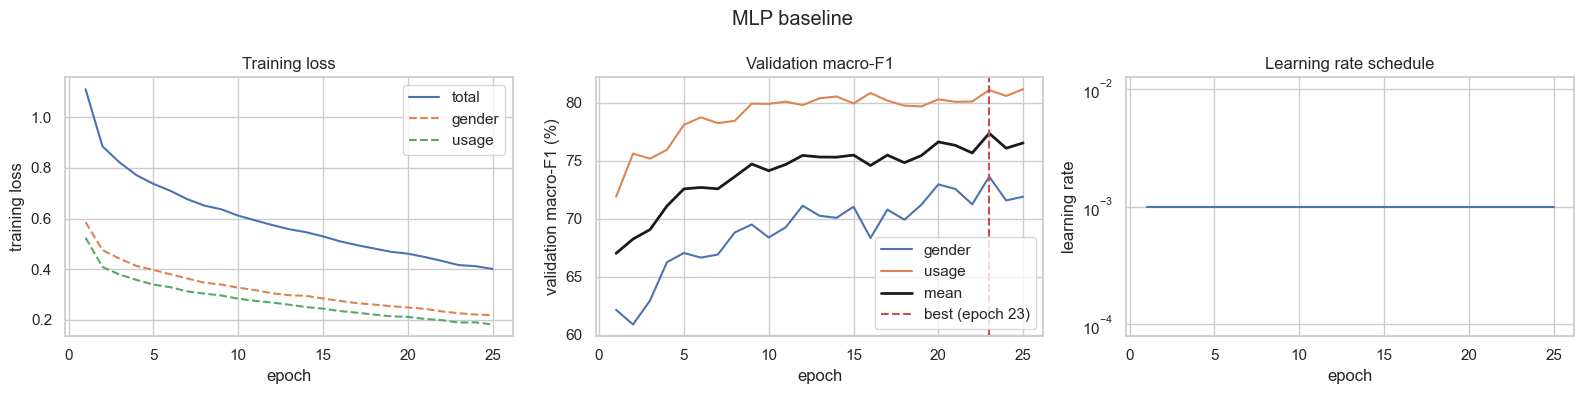

In [23]:
# ============================================
# CELL 22 - Ablation 1: MLP baseline
# ============================================
# Establishes that convolution is doing real work rather than assuming it.

run_experiment("MLP", lambda: MultiTaskMLP(NUM_CLASSES),
               augmentation="none", class_weights=False)
plot_history(HISTORIES["MLP"], "MLP baseline")

[CNN_none] epoch   1/25 loss 1.1855 | val F1 gender 52.29 usage 66.34 mean 59.31  <- best
[CNN_none] epoch   2/25 loss 0.8582 | val F1 gender 50.22 usage 67.17 mean 58.70
[CNN_none] epoch   3/25 loss 0.7529 | val F1 gender 61.83 usage 74.04 mean 67.93  <- best
[CNN_none] epoch   4/25 loss 0.6800 | val F1 gender 66.72 usage 76.20 mean 71.46  <- best
[CNN_none] epoch   5/25 loss 0.6283 | val F1 gender 64.17 usage 77.47 mean 70.82
[CNN_none] epoch   6/25 loss 0.5808 | val F1 gender 69.87 usage 78.20 mean 74.03  <- best
[CNN_none] epoch   7/25 loss 0.5408 | val F1 gender 67.63 usage 76.56 mean 72.09
[CNN_none] epoch   8/25 loss 0.5012 | val F1 gender 71.07 usage 79.25 mean 75.16  <- best
[CNN_none] epoch   9/25 loss 0.4629 | val F1 gender 67.20 usage 79.97 mean 73.58
[CNN_none] epoch  10/25 loss 0.4241 | val F1 gender 62.73 usage 73.07 mean 67.90
[CNN_none] epoch  11/25 loss 0.3974 | val F1 gender 69.36 usage 75.01 mean 72.19
[CNN_none] epoch  12/25 loss 0.3576 | val F1 gender 73.52 usage 

,Model,Target,accuracy,macro_f1,weighted_f1,balanced_acc
0,CNN_none,gender,86.58,71.07,86.55,71.08
1,CNN_none,usage,87.68,79.25,87.93,80.50


Exact match (both correct): 75.66%


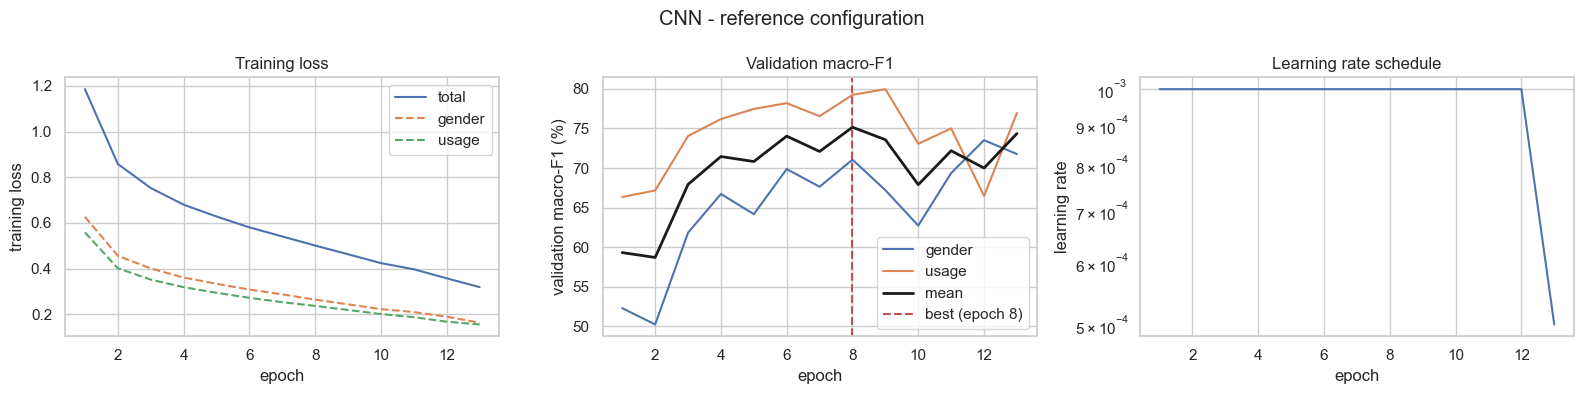

In [24]:
# ============================================
# CELL 23 - Ablation 2: CNN, no augmentation, no class weights (reference)
# ============================================

run_experiment("CNN_none", lambda: MultiTaskCNN(NUM_CLASSES),
               augmentation="none", class_weights=False)
plot_history(HISTORIES["CNN_none"], "CNN - reference configuration")

[CNN_heavy_aug] epoch   1/25 loss 1.3816 | val F1 gender 32.08 usage 51.66 mean 41.87  <- best
[CNN_heavy_aug] epoch   2/25 loss 1.0825 | val F1 gender 55.29 usage 50.92 mean 53.11  <- best
[CNN_heavy_aug] epoch   3/25 loss 0.9730 | val F1 gender 56.56 usage 63.38 mean 59.97  <- best
[CNN_heavy_aug] epoch   4/25 loss 0.9108 | val F1 gender 54.13 usage 73.36 mean 63.75  <- best
[CNN_heavy_aug] epoch   5/25 loss 0.8564 | val F1 gender 61.20 usage 64.98 mean 63.09
[CNN_heavy_aug] epoch   6/25 loss 0.8231 | val F1 gender 59.42 usage 74.48 mean 66.95  <- best
[CNN_heavy_aug] epoch   7/25 loss 0.7917 | val F1 gender 67.28 usage 75.81 mean 71.54  <- best
[CNN_heavy_aug] epoch   8/25 loss 0.7712 | val F1 gender 65.46 usage 73.39 mean 69.43
[CNN_heavy_aug] epoch   9/25 loss 0.7388 | val F1 gender 70.23 usage 75.43 mean 72.83  <- best
[CNN_heavy_aug] epoch  10/25 loss 0.7317 | val F1 gender 68.71 usage 76.34 mean 72.53
[CNN_heavy_aug] epoch  11/25 loss 0.7041 | val F1 gender 68.25 usage 76.20 me

,Model,Target,accuracy,macro_f1,weighted_f1,balanced_acc
0,CNN_heavy_aug,gender,87.53,72.12,87.59,74.3
1,CNN_heavy_aug,usage,89.33,82.38,89.49,84.3


Exact match (both correct): 78.21%


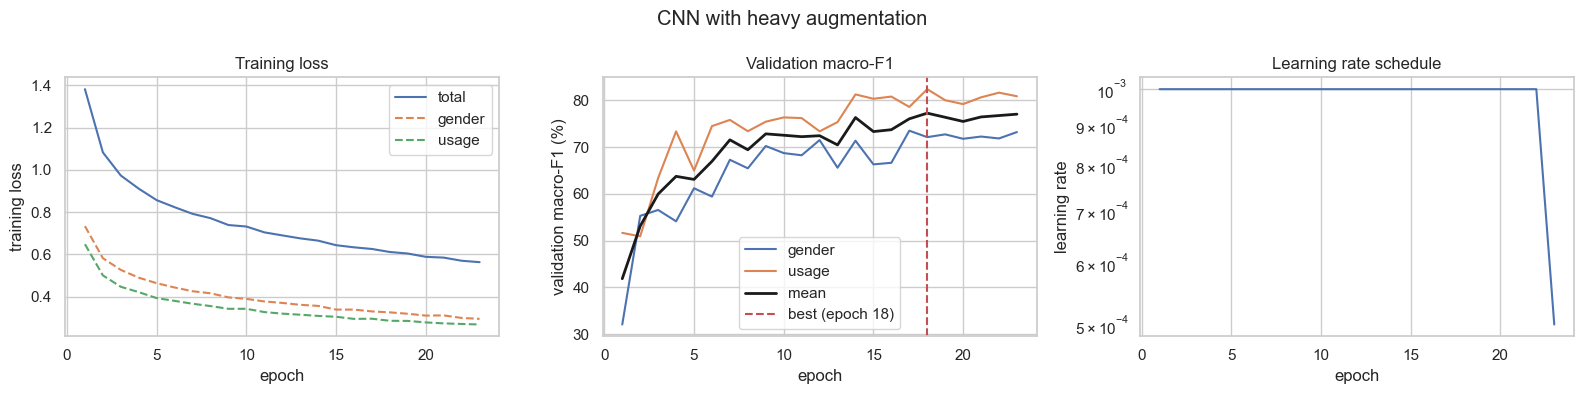

In [25]:
# ============================================
# CELL 24 - Ablation 3: CNN + heavy augmentation
# ============================================
# RUN 1 showed this costs roughly 11 macro-F1 points. Kept as the evidence.

run_experiment("CNN_heavy_aug", lambda: MultiTaskCNN(NUM_CLASSES),
               augmentation="heavy", class_weights=False)
plot_history(HISTORIES["CNN_heavy_aug"], "CNN with heavy augmentation")

[CNN_weighted] epoch   1/25 loss 2.0011 | val F1 gender 36.18 usage 31.30 mean 33.74  <- best
[CNN_weighted] epoch   2/25 loss 1.5068 | val F1 gender 46.87 usage 58.13 mean 52.50  <- best
[CNN_weighted] epoch   3/25 loss 1.3032 | val F1 gender 56.41 usage 44.35 mean 50.38
[CNN_weighted] epoch   4/25 loss 1.1790 | val F1 gender 50.89 usage 63.94 mean 57.42  <- best
[CNN_weighted] epoch   5/25 loss 1.0825 | val F1 gender 58.57 usage 67.97 mean 63.27  <- best
[CNN_weighted] epoch   6/25 loss 0.9812 | val F1 gender 52.59 usage 68.57 mean 60.58
[CNN_weighted] epoch   7/25 loss 0.9067 | val F1 gender 50.05 usage 64.58 mean 57.31
[CNN_weighted] epoch   8/25 loss 0.8426 | val F1 gender 65.67 usage 63.92 mean 64.80  <- best
[CNN_weighted] epoch   9/25 loss 0.7904 | val F1 gender 71.18 usage 65.87 mean 68.52  <- best
[CNN_weighted] epoch  10/25 loss 0.7135 | val F1 gender 66.55 usage 78.35 mean 72.45  <- best
[CNN_weighted] epoch  11/25 loss 0.6681 | val F1 gender 62.29 usage 71.88 mean 67.08
[C

,Model,Target,accuracy,macro_f1,weighted_f1,balanced_acc
0,CNN_weighted,gender,84.71,73.64,85.97,79.85
1,CNN_weighted,usage,88.55,81.41,88.84,84.36


Exact match (both correct): 75.17%


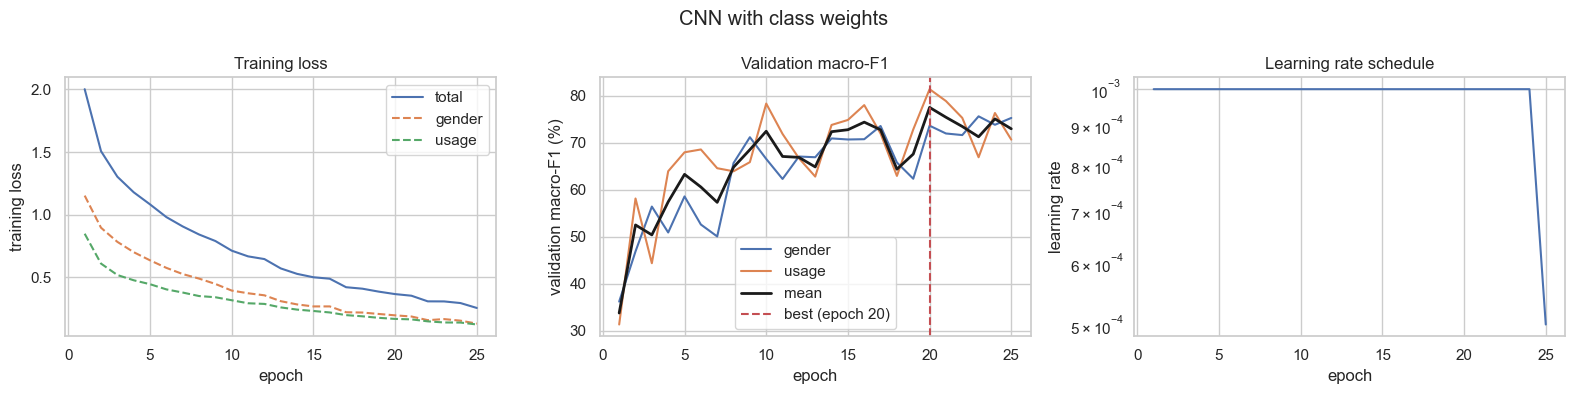

In [26]:
# ============================================
# CELL 25 - Ablation 4: CNN + class weights
# ============================================
# RUN 1: no gain, and it inverted the confidence calibration used in Cell 38.

run_experiment("CNN_weighted", lambda: MultiTaskCNN(NUM_CLASSES),
               augmentation="none", class_weights=True)
plot_history(HISTORIES["CNN_weighted"], "CNN with class weights")

accuracy        macro_f1        balanced_acc       
Target          gender  usage   gender  usage       gender  usage
Model                                                            
CNN_heavy_aug    87.53  89.33    72.12  82.38        74.30  84.30
CNN_none         86.58  87.68    71.07  79.25        71.08  80.50
CNN_weighted     84.71  88.55    73.64  81.41        79.85  84.36
MLP              87.35  89.02    73.63  81.10        73.09  80.55

,Model,GenderF1,UsageF1,MeanF1,ExactMatch,Params,Epochs
3,CNN_weighted,73.64,81.41,77.52,75.17,1240169,25
0,MLP,73.63,81.10,77.37,77.81,7508489,25
2,CNN_heavy_aug,72.12,82.38,77.25,78.21,1240169,23
1,CNN_none,71.07,79.25,75.16,75.66,1240169,13



Effect on validation mean macro-F1 (positive = helps):


,Change,Delta
0,convolution instead of MLP,-2.21
1,add heavy augmentation,2.09
2,add class weights,2.36


Compare each Delta against the cross-validation standard deviation computed
later. Anything smaller than that is noise, not a finding.


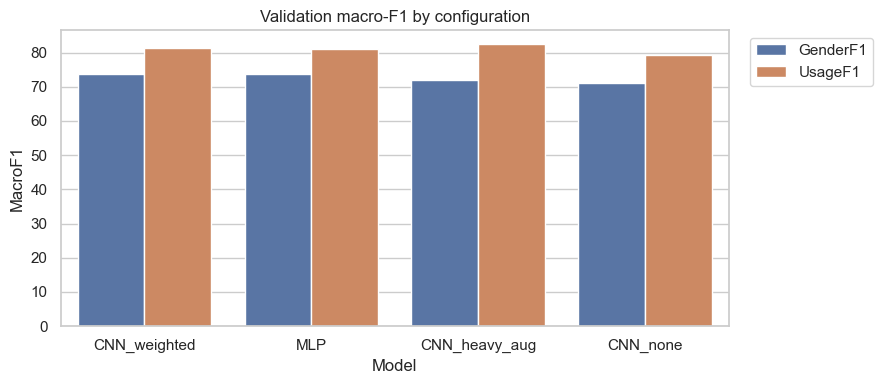

In [27]:
# ============================================
# CELL 26 - Compare the ablations
# ============================================

comparison = pd.concat([metrics_frame(RESULTS[name], name) for name in RESULTS],
                       ignore_index=True)
display(comparison.pivot(index="Model", columns="Target",
                         values=["accuracy", "macro_f1", "balanced_acc"]).round(2))

overview = pd.DataFrame([
    {
        "Model": name,
        "GenderF1": round(RESULTS[name]["gender"]["macro_f1"], 2),
        "UsageF1": round(RESULTS[name]["usage"]["macro_f1"], 2),
        "MeanF1": round(RESULTS[name]["mean_macro_f1"], 2),
        "ExactMatch": round(RESULTS[name]["joint"]["exact_match"], 2),
        "Params": count_parameters(MODELS[name]),
        "Epochs": len(HISTORIES[name]),
    }
    for name in RESULTS
]).sort_values("MeanF1", ascending=False)
display(overview)

# Effect of each single change relative to the reference configuration
reference = RESULTS["CNN_none"]["mean_macro_f1"]
effects = pd.DataFrame([
    {"Change": "convolution instead of MLP",
     "Delta": round(reference - RESULTS["MLP"]["mean_macro_f1"], 2)},
    {"Change": "add heavy augmentation",
     "Delta": round(RESULTS["CNN_heavy_aug"]["mean_macro_f1"] - reference, 2)},
    {"Change": "add class weights",
     "Delta": round(RESULTS["CNN_weighted"]["mean_macro_f1"] - reference, 2)},
])
print("\nEffect on validation mean macro-F1 (positive = helps):")
display(effects)
print("Compare each Delta against the cross-validation standard deviation computed")
print("later. Anything smaller than that is noise, not a finding.")

fig, ax = plt.subplots(figsize=(9, 4))
plot_data = overview.melt(id_vars="Model", value_vars=["GenderF1", "UsageF1"],
                          var_name="Head", value_name="MacroF1")
sns.barplot(data=plot_data, x="Model", y="MacroF1", hue="Head", ax=ax)
ax.set_title("Validation macro-F1 by configuration")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 11. Hyper-parameter search

Random search over the configuration space, scored on validation. The space is **narrowed
around the RUN 1 winner** (`lr = 1e-3`, `widths = (48, 96, 192, 384)`, `dropout = 0.3`), which
is why 4 trials now suffice where 8 were needed to explore blindly.

Critically, the search now trains **without augmentation**. In RUN 1 every trial was augmented,
so the entire search was capped roughly 8 points below the un-augmented reference model — the
search could not have found the best configuration no matter how many trials it ran.

In [28]:
# ============================================
# CELL 27 - Random hyper-parameter search
# ============================================

SEARCH_BUDGET = CONFIG["search_budget"]

# Narrowed around the RUN 1 winner. The three parameters that clearly mattered
# (learning rate, network width, dropout) keep 2 candidate values each; the rest
# are fixed at their winning value to spend the budget where it counts.
SEARCH_SPACE = {
    "learning_rate": [5e-4, 1e-3],
    "weight_decay": [1e-4, 5e-4],
    "dropout": [0.3, 0.4],
    "widths": [(48, 96, 192, 384), (32, 64, 128, 256)],
    "head_hidden": [128],
    "label_smoothing": [0.05],
    "usage_weight": [1.0, 1.5],
}

rng = np.random.default_rng(RANDOM_STATE)
search_rows = []
best_trial = None
seen = set()

for trial in range(SEARCH_BUDGET):
    # avoid spending budget on a duplicate configuration
    for _ in range(50):
        sampled = {k: v[rng.integers(len(v))] for k, v in SEARCH_SPACE.items()}
        key = tuple(str(sampled[k]) for k in sorted(sampled))
        if key not in seen:
            seen.add(key)
            break

    print(f"\n=== trial {trial + 1}/{SEARCH_BUDGET} === {sampled}")

    set_seed(RANDOM_STATE + trial)
    model = MultiTaskCNN(
        NUM_CLASSES,
        widths=tuple(sampled["widths"]),
        dropout=float(sampled["dropout"]),
        head_hidden=int(sampled["head_hidden"]),
    )
    trial_config = {
        "learning_rate": float(sampled["learning_rate"]),
        "weight_decay": float(sampled["weight_decay"]),
        "label_smoothing": float(sampled["label_smoothing"]),
        "task_weights": {"gender": 1.0, "usage": float(sampled["usage_weight"])},
        "max_epochs": 35,
        "early_stopping_patience": 6,
        "use_class_weights": CONFIG["use_class_weights"],
    }

    model, history = train_model(model, train_loader, val_loader,
                                 config=trial_config, tag=f"trial{trial + 1}",
                                 verbose=False)
    summary = summarise(predict(model, val_loader))

    row = {**{k: str(v) for k, v in sampled.items()},
           "GenderF1": round(summary["gender"]["macro_f1"], 2),
           "UsageF1": round(summary["usage"]["macro_f1"], 2),
           "MeanF1": round(summary["mean_macro_f1"], 2),
           "Epochs": len(history)}
    search_rows.append(row)
    print(f"    mean macro-F1 = {row['MeanF1']}")

    if best_trial is None or row["MeanF1"] > best_trial["row"]["MeanF1"]:
        best_trial = {"row": row, "sampled": sampled, "config": trial_config,
                      "model": model, "history": history}

search_df = pd.DataFrame(search_rows).sort_values("MeanF1", ascending=False)
display(search_df)
print("\nBest sampled configuration:", best_trial["sampled"])
print(f"Best search trial mean macro-F1: {best_trial['row']['MeanF1']}")
print(f"Ablation reference (CNN_none)  : {RESULTS['CNN_none']['mean_macro_f1']:.2f}")
print("If the search does not beat the reference, the reference is the better model")
print("and Cell 34 will select it - that is the point of including it as a candidate.")


=== trial 1/4 === {'learning_rate': 0.0005, 'weight_decay': 0.0005, 'dropout': 0.4, 'widths': (48, 96, 192, 384), 'head_hidden': 128, 'label_smoothing': 0.05, 'usage_weight': 1.0}
    mean macro-F1 = 81.96

=== trial 2/4 === {'learning_rate': 0.001, 'weight_decay': 0.0001, 'dropout': 0.4, 'widths': (48, 96, 192, 384), 'head_hidden': 128, 'label_smoothing': 0.05, 'usage_weight': 1.0}
    mean macro-F1 = 82.85

=== trial 3/4 === {'learning_rate': 0.001, 'weight_decay': 0.0005, 'dropout': 0.4, 'widths': (32, 64, 128, 256), 'head_hidden': 128, 'label_smoothing': 0.05, 'usage_weight': 1.5}
    mean macro-F1 = 81.29

=== trial 4/4 === {'learning_rate': 0.001, 'weight_decay': 0.0005, 'dropout': 0.3, 'widths': (32, 64, 128, 256), 'head_hidden': 128, 'label_smoothing': 0.05, 'usage_weight': 1.0}
    mean macro-F1 = 82.05


,learning_rate,weight_decay,dropout,widths,head_hidden,label_smoothing,usage_weight,GenderF1,UsageF1,MeanF1,Epochs
1,0.001,0.0001,0.4,"(48, 96, 192, 384)",128,0.05,1.0,80.84,84.86,82.85,22
3,0.001,0.0005,0.3,"(32, 64, 128, 256)",128,0.05,1.0,79.04,85.06,82.05,35
0,0.0005,0.0005,0.4,"(48, 96, 192, 384)",128,0.05,1.0,79.26,84.67,81.96,23
2,0.001,0.0005,0.4,"(32, 64, 128, 256)",128,0.05,1.5,77.84,84.74,81.29,28



Best sampled configuration: {'learning_rate': 0.001, 'weight_decay': 0.0001, 'dropout': 0.4, 'widths': (48, 96, 192, 384), 'head_hidden': 128, 'label_smoothing': 0.05, 'usage_weight': 1.0}
Best search trial mean macro-F1: 82.85
Ablation reference (CNN_none)  : 75.16
If the search does not beat the reference, the reference is the better model
and Cell 34 will select it - that is the point of including it as a candidate.


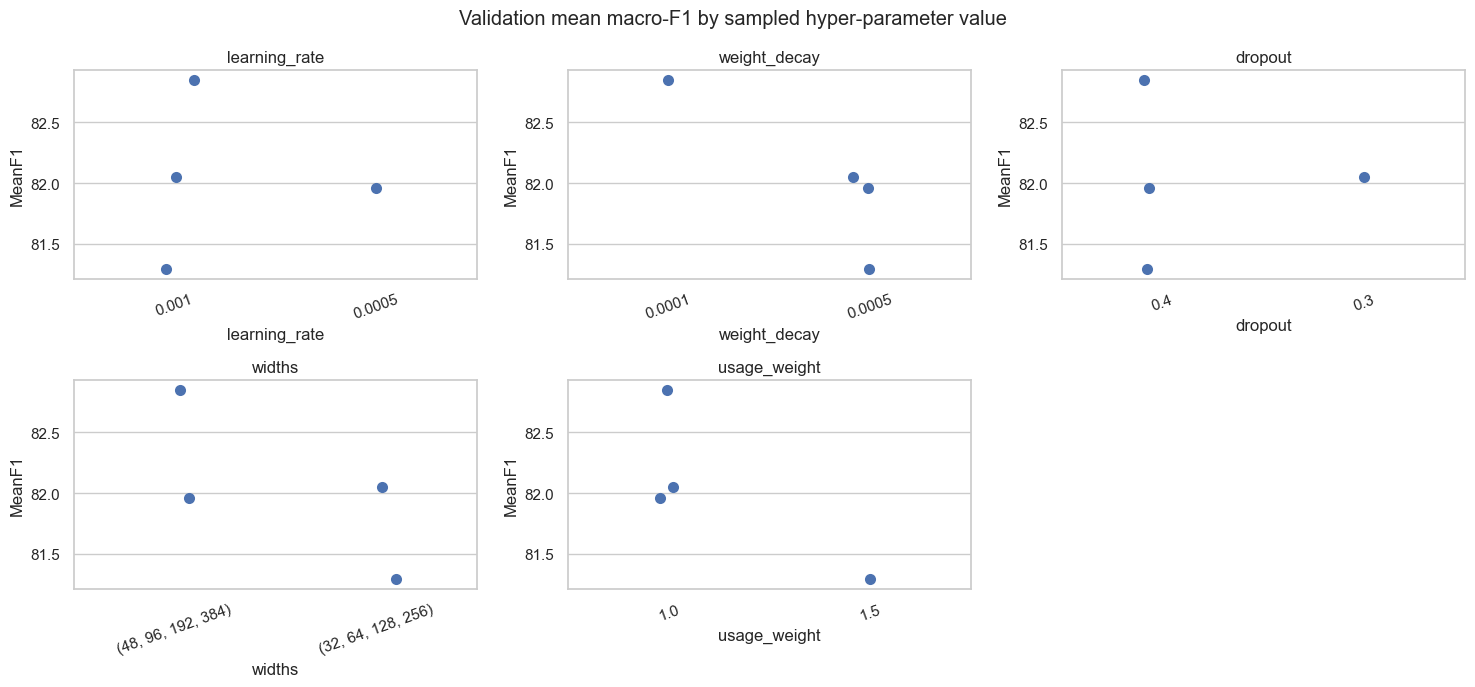

With a budget of 4 these plots indicate direction, not significance.
Treat a parameter as important only if its spread exceeds the seed-to-seed
variation measured by the cross-validation below.


In [29]:
# ============================================
# CELL 28 - Which hyper-parameters actually mattered?
# ============================================

varied = [k for k, v in SEARCH_SPACE.items() if len(v) > 1]
if len(search_df) >= 2 and varied:
    cols = min(3, len(varied))
    rows = int(np.ceil(len(varied) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 3.5 * rows), squeeze=False)
    for ax, parameter in zip(axes.ravel(), varied):
        sns.stripplot(data=search_df, x=parameter, y="MeanF1", ax=ax, size=8)
        ax.set_title(parameter)
        ax.tick_params(axis="x", rotation=20)
    for ax in axes.ravel()[len(varied):]:
        ax.axis("off")
    plt.suptitle("Validation mean macro-F1 by sampled hyper-parameter value")
    plt.tight_layout()
    plt.show()

print("With a budget of", SEARCH_BUDGET, "these plots indicate direction, not significance.")
print("Treat a parameter as important only if its spread exceeds the seed-to-seed")
print("variation measured by the cross-validation below.")

Search improved on the reference (82.85 vs 75.16).


,Model,Target,accuracy,macro_f1,weighted_f1,balanced_acc
0,CNN_tuned,gender,90.73,80.84,90.55,77.00
1,CNN_tuned,usage,90.95,84.86,91.01,84.69


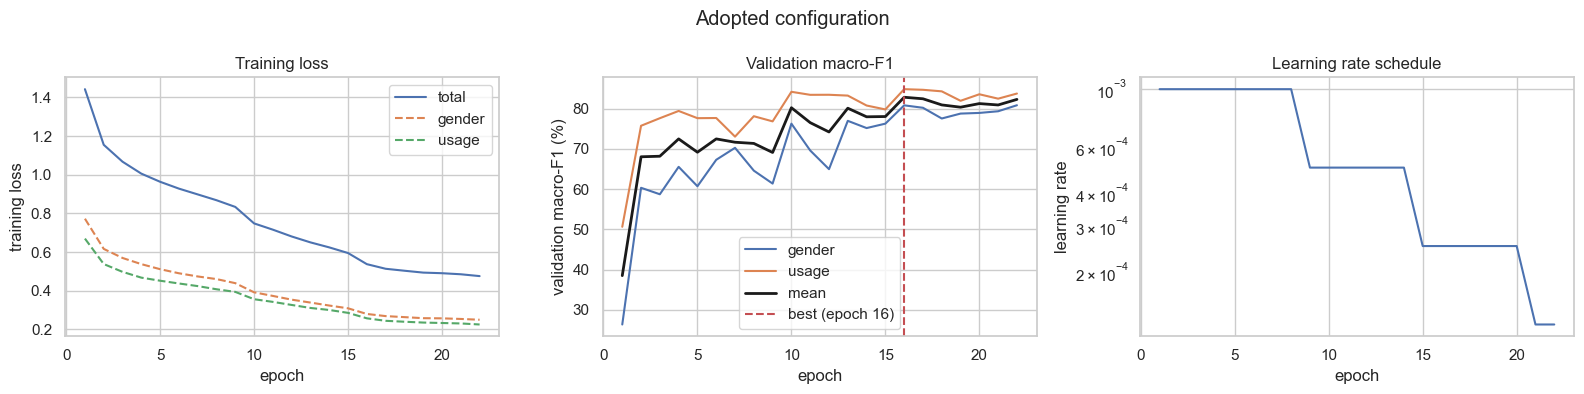

Saved c:\Users\LEGION\Documents\jupyter_notebook\Fashion-Intelligence-System\artifacts\task3\best_config.json


In [30]:
# ============================================
# CELL 29 - Adopt the best configuration
# ============================================

REFERENCE_SCORE = RESULTS["CNN_none"]["mean_macro_f1"]

if best_trial["row"]["MeanF1"] >= REFERENCE_SCORE:
    BEST = best_trial["sampled"]
    BEST_CONFIG = best_trial["config"]
    MODELS["CNN_tuned"] = best_trial["model"]
    HISTORIES["CNN_tuned"] = best_trial["history"]
    RESULTS["CNN_tuned"] = summarise(predict(best_trial["model"], val_loader))
    print(f"Search improved on the reference "
          f"({best_trial['row']['MeanF1']:.2f} vs {REFERENCE_SCORE:.2f}).")
else:
    # The search failed to beat the default architecture. Adopt the reference
    # configuration rather than pretending the search won - this is a legitimate
    # outcome and should be stated in the report.
    BEST = {"learning_rate": CONFIG["learning_rate"],
            "weight_decay": CONFIG["weight_decay"],
            "dropout": 0.4,
            "widths": (32, 64, 128, 256),
            "head_hidden": 128,
            "label_smoothing": 0.0,
            "usage_weight": 1.0}
    BEST_CONFIG = {"learning_rate": CONFIG["learning_rate"],
                   "weight_decay": CONFIG["weight_decay"],
                   "label_smoothing": 0.0,
                   "task_weights": {"gender": 1.0, "usage": 1.0},
                   "max_epochs": 35,
                   "early_stopping_patience": 6,
                   "use_class_weights": CONFIG["use_class_weights"]}
    MODELS["CNN_tuned"] = MODELS["CNN_none"]
    HISTORIES["CNN_tuned"] = HISTORIES["CNN_none"]
    RESULTS["CNN_tuned"] = RESULTS["CNN_none"]
    print(f"Search did NOT beat the reference "
          f"({best_trial['row']['MeanF1']:.2f} vs {REFERENCE_SCORE:.2f}).")
    print("Adopting the reference configuration. Report this honestly - a search")
    print("that fails to improve is a result, not a failure to be hidden.")


def build_best_model():
    return MultiTaskCNN(
        NUM_CLASSES,
        widths=tuple(BEST["widths"]),
        dropout=float(BEST["dropout"]),
        head_hidden=int(BEST["head_hidden"]),
    )


display(metrics_frame(RESULTS["CNN_tuned"], "CNN_tuned"))
plot_history(HISTORIES["CNN_tuned"], "Adopted configuration")

with open(ARTIFACT_DIR / "best_config.json", "w") as f:
    json.dump({"sampled": {k: str(v) for k, v in BEST.items()},
               "train_config": BEST_CONFIG,
               "beat_reference": bool(best_trial["row"]["MeanF1"] >= REFERENCE_SCORE)},
              f, indent=2)
print("Saved", ARTIFACT_DIR / "best_config.json")

## 12. Cross-validation of the chosen configuration

The hold-out estimate comes from a single partition, so it carries sampling variance that a
single number hides. The chosen configuration is re-fitted under **grouped, stratified
cross-validation** (`CONFIG["cv_folds"]`, default 3) on the combined train+validation data. The
held-out test split stays untouched.

Its purpose is **not** model selection — that is the hold-out's job. It produces a standard
deviation, `CV_STD`, which becomes the noise floor used everywhere below: any difference
between two models smaller than `CV_STD` is not evidence of anything. Three folds are enough
for that; raise to 5 for a tighter interval in the final reported run.

In [31]:
# ============================================
# CELL 30 - Grouped cross-validation of the chosen configuration
# ============================================

CV_FOLDS = CONFIG["cv_folds"]
cv_pool = pd.concat([train_df, val_df], ignore_index=True)
cv_groups = cv_pool[CONFIG["group_column"]].fillna(cv_pool["id"].astype(str))

splitter = StratifiedGroupKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []

for fold, (fit_idx, hold_idx) in enumerate(
        splitter.split(cv_pool, cv_pool["_strat"], cv_groups), start=1):

    fold_train = cv_pool.iloc[fit_idx]
    fold_val = cv_pool.iloc[hold_idx]
    assert not (set(fold_train["id"]) & set(fold_val["id"]))

    set_seed(RANDOM_STATE + fold)
    model, history = train_model(
        build_best_model(),
        make_loader(fold_train, train=True),
        make_loader(fold_val),
        config=BEST_CONFIG, tag=f"fold{fold}", verbose=False,
    )
    summary = summarise(predict(model, make_loader(fold_val)))

    cv_rows.append({
        "Fold": fold,
        "n_train": len(fold_train),
        "n_val": len(fold_val),
        "GenderF1": summary["gender"]["macro_f1"],
        "UsageF1": summary["usage"]["macro_f1"],
        "MeanF1": summary["mean_macro_f1"],
        "GenderAcc": summary["gender"]["accuracy"],
        "UsageAcc": summary["usage"]["accuracy"],
        "ExactMatch": summary["joint"]["exact_match"],
        "Epochs": len(history),
    })
    print(f"fold {fold}: mean macro-F1 {summary['mean_macro_f1']:.2f}")

cv_df = pd.DataFrame(cv_rows)
display(cv_df.round(2))

numeric = ["GenderF1", "UsageF1", "MeanF1", "GenderAcc", "UsageAcc", "ExactMatch"]
cv_summary = cv_df[numeric].agg(["mean", "std"]).T.round(2)
cv_summary["95% CI"] = [
    f"{m - 1.96 * s / np.sqrt(CV_FOLDS):.2f} - {m + 1.96 * s / np.sqrt(CV_FOLDS):.2f}"
    for m, s in zip(cv_summary["mean"], cv_summary["std"])
]
display(cv_summary)

CV_STD = float(cv_df["MeanF1"].std())
print(f"\nNOISE FLOOR: differences smaller than +-{CV_STD:.2f} macro-F1 points are")
print("not evidence of anything. Use this number when comparing models above.")

fold 1: mean macro-F1 81.24
fold 2: mean macro-F1 76.12
fold 3: mean macro-F1 79.89


,Fold,n_train,n_val,GenderF1,UsageF1,MeanF1,GenderAcc,UsageAcc,ExactMatch,Epochs
0,1,21969,10984,77.31,85.18,81.24,90.04,91.66,82.50,26
1,2,21969,10984,72.20,80.05,76.12,87.84,89.31,78.53,12
2,3,21968,10985,76.35,83.43,79.89,90.38,91.22,82.49,35


,mean,std,95% CI
GenderF1,75.28,2.72,72.20 - 78.36
UsageF1,82.88,2.61,79.93 - 85.83
MeanF1,79.08,2.65,76.08 - 82.08
GenderAcc,89.42,1.38,87.86 - 90.98
UsageAcc,90.73,1.25,89.32 - 92.14
ExactMatch,81.17,2.29,78.58 - 83.76



NOISE FLOOR: differences smaller than +-2.65 macro-F1 points are
not evidence of anything. Use this number when comparing models above.


## 13. Post-pruning — magnitude pruning and fine-tuning

Post-pruning removes capacity *after* convergence. Global L1-unstructured pruning zeroes the
smallest-magnitude weights across all convolutional and linear layers, followed by a short
fine-tune so the surviving weights can compensate.

**Confound fixed from RUN 1.** Previously the unpruned baseline received no fine-tuning while
the pruned models each got 5 extra epochs, so a pruned model appearing to *beat* the baseline
was not interpretable. The 0% level now receives an identical fine-tune, making the comparison
fair. Sparsity levels are reduced to three, since RUN 1 established the shape of the curve.

In [32]:
# ============================================
# CELL 31 - Global magnitude pruning across sparsity levels
# ============================================

import torch.nn.utils.prune as prune

SPARSITY_LEVELS = [0.0, 0.5, 0.8]     # RUN 1 mapped the full curve; these bracket it
FINE_TUNE_EPOCHS = 5

base_state = copy.deepcopy(MODELS["CNN_tuned"].state_dict())
prune_rows = []


def prunable_parameters(model):
    return [(m, "weight") for m in model.modules()
            if isinstance(m, (nn.Conv2d, nn.Linear))]


def sparsity_of(model):
    total = zeros = 0
    for module, _ in prunable_parameters(model):
        total += module.weight.numel()
        zeros += int((module.weight == 0).sum())
    return zeros / total * 100


fine_tune_config = {**BEST_CONFIG,
                    "max_epochs": FINE_TUNE_EPOCHS,
                    "early_stopping_patience": FINE_TUNE_EPOCHS,
                    "learning_rate": BEST_CONFIG["learning_rate"] * 0.2}

for amount in SPARSITY_LEVELS:
    model = build_best_model().to(DEVICE)
    model.load_state_dict(base_state)

    parameters = prunable_parameters(model)
    if amount > 0:
        prune.global_unstructured(parameters, pruning_method=prune.L1Unstructured,
                                  amount=amount)

    # EVERY level is fine-tuned for the same number of epochs, including 0%.
    # Without this the comparison confounds pruning with extra training.
    model, _ = train_model(model, train_loader, val_loader, config=fine_tune_config,
                           tag=f"prune{int(amount * 100)}", verbose=False)

    if amount > 0:
        for module, name in parameters:
            prune.remove(module, name)      # bake the mask into the weights

    summary = summarise(predict(model, val_loader))
    nonzero = sum(int((m.weight != 0).sum()) for m, _ in prunable_parameters(model))

    prune_rows.append({
        "Sparsity%": amount * 100,
        "ActualZero%": round(sparsity_of(model), 1),
        "NonZeroWeights": nonzero,
        "GenderF1": round(summary["gender"]["macro_f1"], 2),
        "UsageF1": round(summary["usage"]["macro_f1"], 2),
        "MeanF1": round(summary["mean_macro_f1"], 2),
    })
    print(f"sparsity {amount:.0%}: mean macro-F1 {summary['mean_macro_f1']:.2f} "
          f"({nonzero:,} non-zero weights)")

    MODELS[f"pruned_{int(amount * 100)}"] = model

prune_df = pd.DataFrame(prune_rows)
display(prune_df)

baseline_f1 = prune_df.loc[prune_df["Sparsity%"] == 0, "MeanF1"].iloc[0]
prune_df["DeltaVsUnpruned"] = (prune_df["MeanF1"] - baseline_f1).round(2)
print("\nAll levels received identical fine-tuning, so DeltaVsUnpruned isolates pruning.")
display(prune_df[["Sparsity%", "NonZeroWeights", "MeanF1", "DeltaVsUnpruned"]])

sparsity 0%: mean macro-F1 82.85 (2,734,224 non-zero weights)
sparsity 50%: mean macro-F1 82.21 (1,367,112 non-zero weights)
sparsity 80%: mean macro-F1 83.10 (546,845 non-zero weights)


,Sparsity%,ActualZero%,NonZeroWeights,GenderF1,UsageF1,MeanF1
0,0.0,0.0,2734224,80.71,85.00,82.85
1,50.0,50.0,1367112,79.45,84.97,82.21
2,80.0,80.0,546845,81.25,84.96,83.10



All levels received identical fine-tuning, so DeltaVsUnpruned isolates pruning.


,Sparsity%,NonZeroWeights,MeanF1,DeltaVsUnpruned
0,0.0,2734224,82.85,0.00
1,50.0,1367112,82.21,-0.64
2,80.0,546845,83.10,0.25


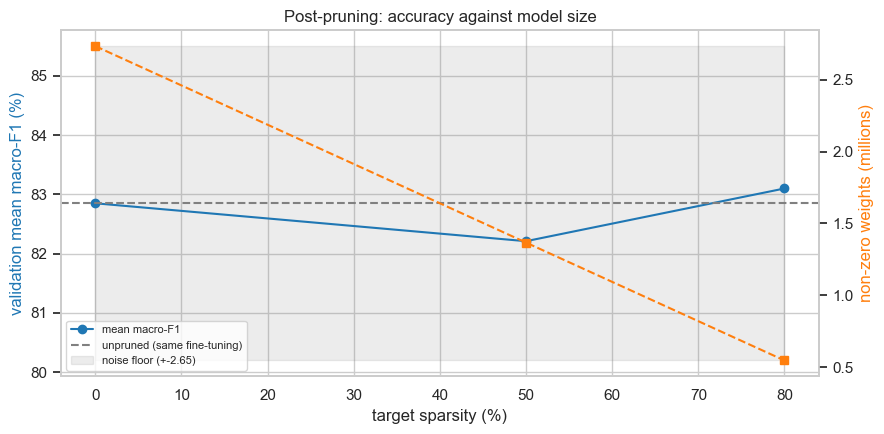

Highest sparsity indistinguishable from unpruned (within +-2.65): 80%
That is the defensible compression claim for the report - not the raw best score,
which will fluctuate inside the noise band from run to run.


In [33]:
# ============================================
# CELL 32 - Accuracy / size trade-off
# ============================================

fig, ax1 = plt.subplots(figsize=(9, 4.5))
ax1.plot(prune_df["Sparsity%"], prune_df["MeanF1"], "o-", color="tab:blue",
         label="mean macro-F1")
ax1.axhline(baseline_f1, ls="--", color="grey", label="unpruned (same fine-tuning)")
ax1.fill_between(prune_df["Sparsity%"], baseline_f1 - CV_STD, baseline_f1 + CV_STD,
                 color="grey", alpha=0.15, label=f"noise floor (+-{CV_STD:.2f})")
ax1.set_xlabel("target sparsity (%)")
ax1.set_ylabel("validation mean macro-F1 (%)", color="tab:blue")

ax2 = ax1.twinx()
ax2.plot(prune_df["Sparsity%"], prune_df["NonZeroWeights"] / 1e6, "s--", color="tab:orange")
ax2.set_ylabel("non-zero weights (millions)", color="tab:orange")
ax2.grid(False)

ax1.set_title("Post-pruning: accuracy against model size")
ax1.legend(loc="lower left", fontsize=8)
plt.tight_layout()
plt.show()

within_noise = prune_df[prune_df["MeanF1"] >= baseline_f1 - CV_STD]
print(f"Highest sparsity indistinguishable from unpruned (within +-{CV_STD:.2f}): "
      f"{within_noise['Sparsity%'].max():.0f}%")
print("That is the defensible compression claim for the report - not the raw best score,")
print("which will fluctuate inside the noise band from run to run.")

## 14. Was multi-task learning the right choice?

The framing decision at the top of the notebook is now tested rather than assumed. Two
single-task networks are trained with the same backbone configuration, the same split and the
same budget. If they beat the shared model, the multi-task claim does not hold and the report
should say so.

In [34]:
# ============================================
# CELL 33 - Single-task controls
# ============================================
# Two networks with one head each, same backbone and budget as the multi-task
# model. This tests the framing decision instead of assuming it.

single_task_results = {}
control_config = {**BEST_CONFIG, "max_epochs": CONFIG["ablation_max_epochs"],
                  "early_stopping_patience": 5}

for target in CONFIG["targets"]:
    set_seed()
    model = MultiTaskCNN(
        {target: NUM_CLASSES[target]},          # one head only
        widths=tuple(BEST["widths"]),
        dropout=float(BEST["dropout"]),
        head_hidden=int(BEST["head_hidden"]),
    )
    model, history = train_model(model, train_loader, val_loader,
                                 config=control_config, tag=f"single_{target}",
                                 verbose=False)
    summary = summarise(predict(model, val_loader))
    single_task_results[target] = summary
    MODELS[f"single_{target}"] = model
    print(f"single-task {target}: macro-F1 {summary[target]['macro_f1']:.2f} "
          f"({len(history)} epochs, {count_parameters(model):,} params)")

multi = RESULTS["CNN_tuned"]
single_vs_multi = pd.DataFrame([
    {
        "Target": target,
        "SingleTaskF1": round(single_task_results[target][target]["macro_f1"], 2),
        "MultiTaskF1": round(multi[target]["macro_f1"], 2),
        "Difference": round(multi[target]["macro_f1"]
                            - single_task_results[target][target]["macro_f1"], 2),
    }
    for target in CONFIG["targets"]
])
display(single_vs_multi)

total_single = sum(count_parameters(MODELS[f"single_{t}"]) for t in CONFIG["targets"])
print(f"Parameters - two single-task models: {total_single:,}")
print(f"Parameters - one multi-task model  : {count_parameters(MODELS['CNN_tuned']):,}")
print(f"Reduction: {(1 - count_parameters(MODELS['CNN_tuned']) / total_single) * 100:.1f}%")

meaningful = single_vs_multi[single_vs_multi["Difference"].abs() > CV_STD]
print(f"\nDifferences exceeding the +-{CV_STD:.2f} noise floor: "
      f"{list(meaningful['Target']) if len(meaningful) else 'none'}")

single-task gender: macro-F1 73.73 (13 epochs, 2,687,573 params)
single-task usage: macro-F1 79.13 (12 epochs, 2,687,444 params)


,Target,SingleTaskF1,MultiTaskF1,Difference
0,gender,73.73,80.84,7.11
1,usage,79.13,84.86,5.73


Parameters - two single-task models: 5,375,017
Parameters - one multi-task model  : 2,737,369
Reduction: 49.1%

Differences exceeding the +-2.65 noise floor: ['gender', 'usage']


## 15. Ultimate judgement and final test evaluation

Every trained model competes, and the winner is evaluated **once** on the held-out test split.

**Bug fixed from RUN 1.** The candidate list previously contained only the tuned and pruned
models, silently excluding the ablation models. Since the un-augmented reference model was
actually the strongest by roughly 7 macro-F1 points, RUN 1 selected and reported a model that
was clearly beaten by one it had already trained. Selection now considers everything in
`MODELS`, and ties within the cross-validation noise floor are broken in favour of the smaller
network, because inference cost matters for the deployed application.

In [35]:
# ============================================
# CELL 34 - Select and evaluate the final model
# ============================================

# Every model that was trained is a candidate. Excluding any of them here is how
# RUN 1 ended up reporting a model that was beaten by one of its own baselines.
CANDIDATES = dict(MODELS)
print("Candidates considered:", len(CANDIDATES))

selection_rows = []
for name, model in CANDIDATES.items():
    if name.startswith("single_"):
        continue          # single-head controls answer a different question
    summary = summarise(predict(model, val_loader))
    selection_rows.append({
        "Model": name,
        "ValMeanF1": round(summary["mean_macro_f1"], 2),
        "ValGenderF1": round(summary["gender"]["macro_f1"], 2),
        "ValUsageF1": round(summary["usage"]["macro_f1"], 2),
        "ValExactMatch": round(summary["joint"]["exact_match"], 2),
        "Params": count_parameters(model),
        "NonZero": sum(int((m.weight != 0).sum()) for m in model.modules()
                       if isinstance(m, (nn.Conv2d, nn.Linear))),
    })

selection_df = pd.DataFrame(selection_rows).sort_values("ValMeanF1", ascending=False)
display(selection_df)

best_score = selection_df.iloc[0]["ValMeanF1"]

# Any model within one noise floor of the best is statistically tied with it;
# among those, prefer the one with the fewest non-zero weights.
tied = selection_df[selection_df["ValMeanF1"] >= best_score - CV_STD]
chosen = tied.sort_values("NonZero").iloc[0]

FINAL_NAME = chosen["Model"]
FINAL_MODEL = CANDIDATES[FINAL_NAME]

print(f"\nBest raw score      : {selection_df.iloc[0]['Model']} ({best_score:.2f})")
print(f"Statistically tied  : {list(tied['Model'])} (within +-{CV_STD:.2f})")
print(f"ULTIMATE JUDGEMENT  : {FINAL_NAME} "
      f"({chosen['ValMeanF1']:.2f} macro-F1, {chosen['NonZero']:,} non-zero weights)")
print("\nRationale: among models that cannot be distinguished statistically, the")
print("smallest is preferred because it is cheaper to serve in the application.")

Candidates considered: 10


,Model,ValMeanF1,ValGenderF1,ValUsageF1,ValExactMatch,Params,NonZero
7,pruned_80,83.10,81.25,84.96,83.09,2737369,546845
4,CNN_tuned,82.85,80.84,84.86,82.76,2737369,2734224
5,pruned_0,82.85,80.71,85.00,82.56,2737369,2734224
6,pruned_50,82.21,79.45,84.97,82.83,2737369,1367112
3,CNN_weighted,77.52,73.64,81.41,75.17,1240169,1237984
0,MLP,77.37,73.63,81.10,77.81,7508489,7506176
2,CNN_heavy_aug,77.25,72.12,82.38,78.21,1240169,1237984
1,CNN_none,75.16,71.07,79.25,75.66,1240169,1237984



Best raw score      : pruned_80 (83.10)
Statistically tied  : ['pruned_80', 'CNN_tuned', 'pruned_0', 'pruned_50'] (within +-2.65)
ULTIMATE JUDGEMENT  : pruned_80 (83.10 macro-F1, 546,845 non-zero weights)

Rationale: among models that cannot be distinguished statistically, the
smallest is preferred because it is cheaper to serve in the application.


In [36]:
# ============================================
# CELL 35 - Held-out test performance
# ============================================

test_predictions = predict(FINAL_MODEL, test_loader)
test_summary = summarise(test_predictions)

final_rows = []
for target in CONFIG["targets"]:
    final_rows.append({
        "Target": target,
        "Accuracy": round(test_summary[target]["accuracy"], 2),
        "MacroF1": round(test_summary[target]["macro_f1"], 2),
        "WeightedF1": round(test_summary[target]["weighted_f1"], 2),
        "BalancedAcc": round(test_summary[target]["balanced_acc"], 2),
        "BaselineAcc": BASELINE[target]["Accuracy"],
        "BaselineF1": BASELINE[target]["MacroF1"],
    })
final_df = pd.DataFrame(final_rows)
final_df["AccGain"] = (final_df["Accuracy"] - final_df["BaselineAcc"]).round(2)
final_df["F1Gain"] = (final_df["MacroF1"] - final_df["BaselineF1"]).round(2)
display(final_df)

print(f"Exact match (both heads correct): "
      f"{test_summary['joint']['exact_match']:.2f}%")
print("Both-correct is the metric that matters for the product: a listing is only")
print("auto-tagged correctly when gender and occasion are both right.")

,Target,Accuracy,MacroF1,WeightedF1,BalancedAcc,BaselineAcc,BaselineF1,AccGain,F1Gain
0,gender,90.35,78.33,90.22,75.13,54.22,14.06,36.13,64.27
1,usage,90.06,83.14,89.99,82.99,77.08,21.76,12.98,61.38


Exact match (both heads correct): 81.32%
Both-correct is the metric that matters for the product: a listing is only
auto-tagged correctly when gender and occasion are both right.


GENDER - test classification report
              precision    recall  f1-score   support

        Boys      0.776     0.716     0.744       116
       Girls      0.902     0.604     0.724        91
         Men      0.916     0.947     0.931      2978
      Unisex      0.615     0.579     0.596       292
       Women      0.932     0.911     0.921      2016

    accuracy                          0.904      5493
   macro avg      0.828     0.751     0.783      5493
weighted avg      0.902     0.904     0.902      5493

USAGE - test classification report
              precision    recall  f1-score   support

      Casual      0.934     0.938     0.936      4235
      Ethnic      0.825     0.899     0.860       367
      Formal      0.873     0.814     0.842       328
      Sports      0.707     0.668     0.687       563

    accuracy                          0.901      5493
   macro avg      0.835     0.830     0.831      5493
weighted avg      0.900     0.901     0.900      5493



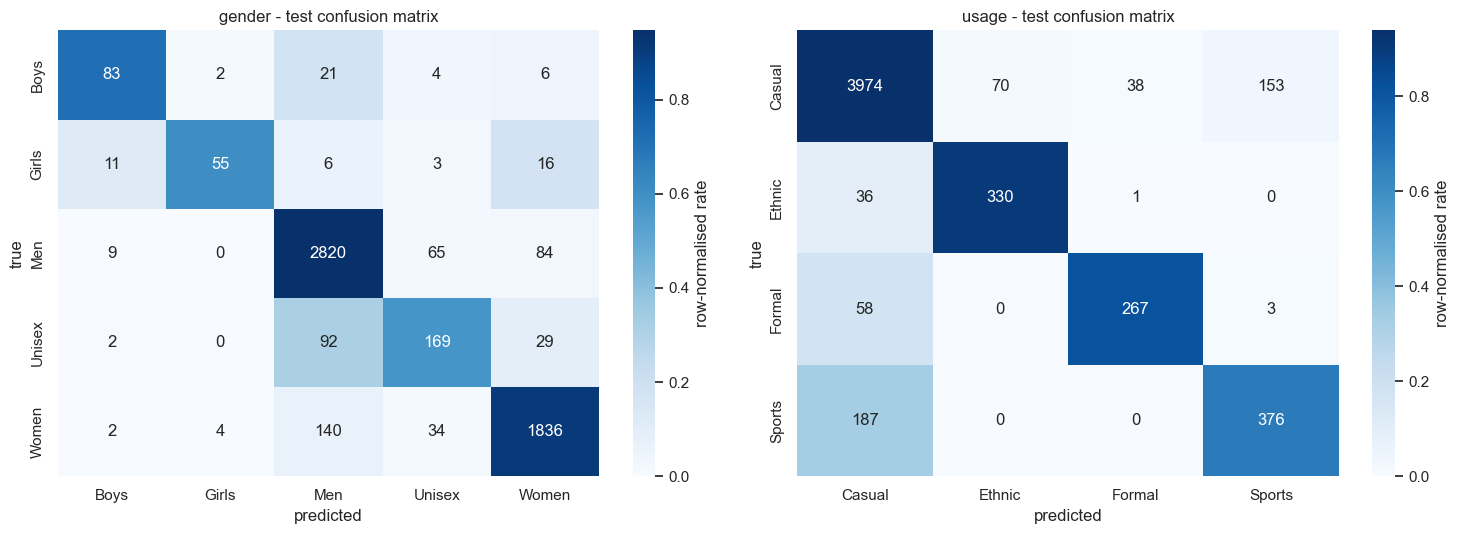

In [37]:
# ============================================
# CELL 36 - Per-class report and confusion matrices
# ============================================

for target in CONFIG["targets"]:
    print("=" * 60)
    print(target.upper(), "- test classification report")
    print("=" * 60)
    print(classification_report(
        test_predictions[target]["true"],
        test_predictions[target]["pred"],
        target_names=class_names[target],
        zero_division=0,
        digits=3,
    ))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for ax, target in zip(axes, CONFIG["targets"]):
    matrix = confusion_matrix(test_predictions[target]["true"],
                              test_predictions[target]["pred"])
    normalised = matrix.astype(float) / matrix.sum(axis=1, keepdims=True).clip(min=1)
    sns.heatmap(normalised, annot=matrix, fmt="d", cmap="Blues", ax=ax,
                xticklabels=class_names[target], yticklabels=class_names[target],
                cbar_kws={"label": "row-normalised rate"})
    ax.set_xlabel("predicted"); ax.set_ylabel("true")
    ax.set_title(f"{target} - test confusion matrix")
plt.tight_layout()
plt.show()


Most common gender confusions (true -> predicted):


Count
gender_label gender_pred       
Women        Men            140
Unisex       Men             92
Men          Women           84
             Unisex          65
Women        Unisex          34
Unisex       Women           29
Boys         Men             21
Girls        Women           16


Most common usage confusions (true -> predicted):


Count
usage_label usage_pred       
Sports      Casual        187
Casual      Sports        153
            Ethnic         70
Formal      Casual         58
Casual      Formal         38
Ethnic      Casual         36
Formal      Sports          3
Ethnic      Formal          1

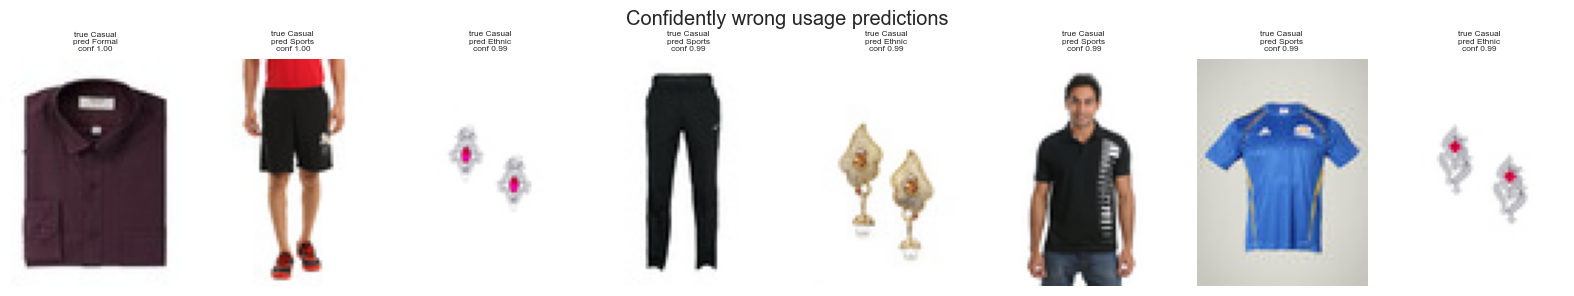

In [38]:
# ============================================
# CELL 37 - Error analysis
# ============================================

errors = test_df.copy().reset_index(drop=True)
for target in CONFIG["targets"]:
    errors[target + "_pred"] = [class_names[target][i]
                                for i in test_predictions[target]["pred"]]
    errors[target + "_conf"] = test_predictions[target]["prob"].max(axis=1)
    errors[target + "_correct"] = (
        test_predictions[target]["true"] == test_predictions[target]["pred"]
    )

# most frequent confusions
for target in CONFIG["targets"]:
    wrong = errors[~errors[target + "_correct"]]
    pairs = (wrong.groupby([target + "_label", target + "_pred"])
             .size().sort_values(ascending=False).head(8))
    print(f"\nMost common {target} confusions (true -> predicted):")
    display(pairs.to_frame("Count"))

# confident mistakes are the most informative failures
worst = errors[~errors["usage_correct"]].nlargest(8, "usage_conf")
fig, axes = plt.subplots(1, 8, figsize=(16, 3))
for ax, (_, row) in zip(axes, worst.iterrows()):
    ax.imshow(np.asarray(IMAGES[row["cache_position"]]))
    ax.set_title(f"true {row['usage_label']}\npred {row['usage_pred']}\n"
                 f"conf {row['usage_conf']:.2f}", fontsize=6)
    ax.axis("off")
plt.suptitle("Confidently wrong usage predictions")
plt.tight_layout()
plt.show()

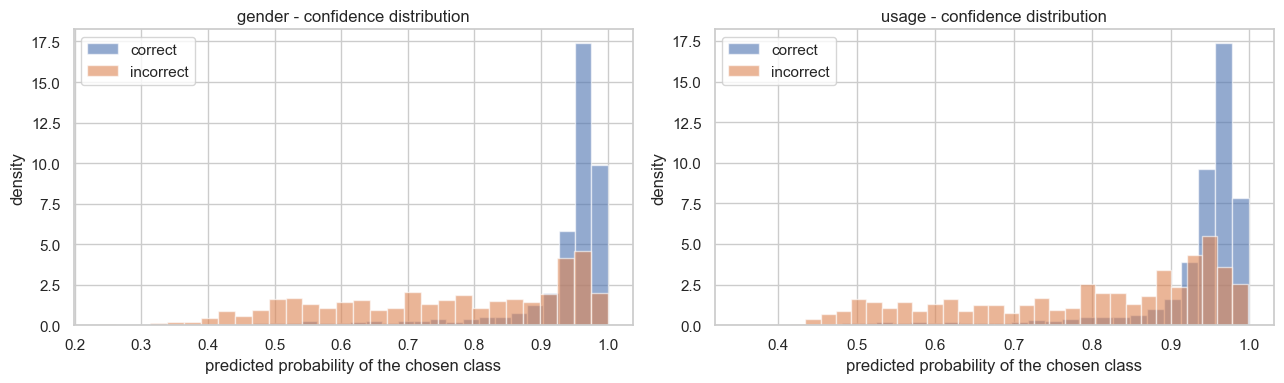

,Target,Threshold,Coverage%,Accuracy%,n
0,gender,0.0,100.0,90.35,5493
1,gender,0.5,98.1,91.17,5388
2,gender,0.6,95.3,92.36,5233
3,gender,0.7,92.2,93.39,5066
4,gender,0.8,88.0,94.93,4834
5,gender,0.9,80.2,96.16,4406
6,usage,0.0,100.0,90.06,5493
7,usage,0.5,99.1,90.44,5441
8,usage,0.6,96.3,91.49,5291
9,usage,0.7,93.9,92.52,5157


Calibration sanity check (accuracy should rise with the threshold):
  gender   PASS  (90.3% -> 96.2%)
  usage    PASS  (90.1% -> 95.6%)


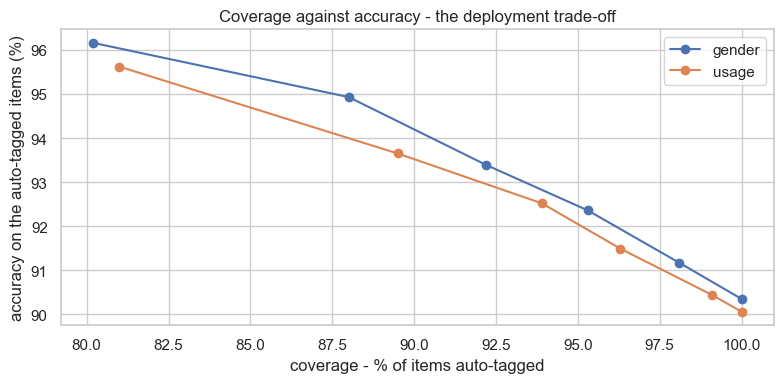

In [39]:
# ============================================
# CELL 38 - Confidence, calibration and an operating threshold
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, target in zip(axes, CONFIG["targets"]):
    for correct, label in [(True, "correct"), (False, "incorrect")]:
        subset = errors[errors[target + "_correct"] == correct][target + "_conf"]
        ax.hist(subset, bins=30, alpha=0.6, label=label, density=True)
    ax.set_xlabel("predicted probability of the chosen class")
    ax.set_ylabel("density")
    ax.set_title(f"{target} - confidence distribution")
    ax.legend()
plt.tight_layout()
plt.show()

# Operating thresholds: auto-tag above, send below to human review.
threshold_rows = []
for target in CONFIG["targets"]:
    for threshold in [0.0, 0.5, 0.6, 0.7, 0.8, 0.9]:
        confident = errors[errors[target + "_conf"] >= threshold]
        if len(confident) < 20:
            continue
        threshold_rows.append({
            "Target": target,
            "Threshold": threshold,
            "Coverage%": round(len(confident) / len(errors) * 100, 1),
            "Accuracy%": round(confident[target + "_correct"].mean() * 100, 2),
            "n": len(confident),
        })

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df)

# A trustworthy model is MORE accurate when it is MORE confident. RUN 1 failed
# this check because class weighting inflated the logits of rare classes.
print("Calibration sanity check (accuracy should rise with the threshold):")
for target in CONFIG["targets"]:
    sub = threshold_df[threshold_df["Target"] == target].sort_values("Threshold")
    monotonic = sub["Accuracy%"].is_monotonic_increasing
    print(f"  {target:8s} {'PASS' if monotonic else 'FAIL - probabilities are miscalibrated'}"
          f"  ({sub['Accuracy%'].iloc[0]:.1f}% -> {sub['Accuracy%'].iloc[-1]:.1f}%)")

fig, ax = plt.subplots(figsize=(8, 4))
for target in CONFIG["targets"]:
    sub = threshold_df[threshold_df["Target"] == target].sort_values("Threshold")
    ax.plot(sub["Coverage%"], sub["Accuracy%"], "o-", label=target)
ax.set_xlabel("coverage - % of items auto-tagged")
ax.set_ylabel("accuracy on the auto-tagged items (%)")
ax.set_title("Coverage against accuracy - the deployment trade-off")
ax.legend()
plt.tight_layout()
plt.show()

## 16. Save artefacts

In [40]:
# ============================================
# CELL 39 - Persist the final model and metadata
# ============================================

MODEL_PATH = ARTIFACT_DIR / "task3_multitask_cnn.pt"

torch.save({
    "state_dict": FINAL_MODEL.state_dict(),
    "model_name": FINAL_NAME,
    "num_classes": NUM_CLASSES,
    "class_names": class_names,
    "channel_mean": CHANNEL_MEAN.tolist(),
    "channel_std": CHANNEL_STD.tolist(),
    "image_size_pil": list(IMAGE_SIZE_PIL),
    "architecture": {
        "widths": list(BEST["widths"]),
        "dropout": float(BEST["dropout"]),
        "head_hidden": int(BEST["head_hidden"]),
    },
    "config": {k: v for k, v in CONFIG.items()},
    "test_metrics": {t: test_summary[t] for t in CONFIG["targets"]},
}, MODEL_PATH)

print("Saved model ->", MODEL_PATH,
      f"({MODEL_PATH.stat().st_size / 1e6:.1f} MB)")

# experiment log for the report
log = pd.DataFrame([
    {"Model": name,
     "GenderF1": round(RESULTS[name]["gender"]["macro_f1"], 2),
     "UsageF1": round(RESULTS[name]["usage"]["macro_f1"], 2),
     "MeanF1": round(RESULTS[name]["mean_macro_f1"], 2)}
    for name in RESULTS
])
log.to_csv(ARTIFACT_DIR / "experiment_log.csv", index=False)
search_df.to_csv(ARTIFACT_DIR / "hyperparameter_search.csv", index=False)
cv_df.to_csv(ARTIFACT_DIR / "cross_validation.csv", index=False)
prune_df.to_csv(ARTIFACT_DIR / "pruning_results.csv", index=False)
final_df.to_csv(ARTIFACT_DIR / "final_test_metrics.csv", index=False)

for path in sorted(ARTIFACT_DIR.iterdir()):
    print(" -", path.name)

Saved model -> c:\Users\LEGION\Documents\jupyter_notebook\Fashion-Intelligence-System\artifacts\task3\task3_multitask_cnn.pt (11.0 MB)
 - best_config.json
 - cross_validation.csv
 - experiment_log.csv
 - final_test_metrics.csv
 - hyperparameter_search.csv
 - label_classes.json
 - pruning_results.csv
 - task3_multitask_cnn.pt
 - task3_predictions.csv
 - task3_summary.json


## 17. Inference on the unlabelled test images

The same `load_image_array` and normalisation used in training are reused here, so training and
inference cannot diverge. The output fills the `gender` and `usage` columns of the prediction
template; the other columns belong to the other tasks in the group.

In [41]:
# ============================================
# CELL 40 - Reusable inference function
# ============================================

def load_task3_model(path=MODEL_PATH, device=DEVICE):
    """Rebuild the trained model from disk - used by the notebook and the app backend."""
    checkpoint = torch.load(path, map_location=device)
    model = MultiTaskCNN(
        checkpoint["num_classes"],
        widths=tuple(checkpoint["architecture"]["widths"]),
        dropout=checkpoint["architecture"]["dropout"],
        head_hidden=checkpoint["architecture"]["head_hidden"],
    )
    model.load_state_dict(checkpoint["state_dict"])
    model.to(device).eval()
    return model, checkpoint


@torch.no_grad()
def predict_images(model, checkpoint, paths, batch_size=256, device=DEVICE):
    """Predict gender and usage for a list of image paths."""
    mean = np.array(checkpoint["channel_mean"], dtype=np.float32)
    std = np.array(checkpoint["channel_std"], dtype=np.float32)
    size = tuple(checkpoint["image_size_pil"])

    outputs = {t: {"label": [], "confidence": []} for t in checkpoint["class_names"]}

    for start in range(0, len(paths), batch_size):
        chunk = paths[start:start + batch_size]
        arrays = np.stack([load_image_array(p, size) for p in chunk]).astype(np.float32) / 255.0
        arrays = (arrays - mean) / std
        tensor = torch.from_numpy(arrays.transpose(0, 3, 1, 2)).float().to(device)

        with amp_autocast():
            logits = model(tensor)

        for target, values in logits.items():
            probabilities = F.softmax(values.float(), dim=1).cpu().numpy()
            indices = probabilities.argmax(1)
            outputs[target]["label"] += [checkpoint["class_names"][target][i] for i in indices]
            outputs[target]["confidence"] += probabilities.max(1).tolist()

    return outputs


final_model, final_checkpoint = load_task3_model()
print("Reloaded model:", final_checkpoint["model_name"])
print("Classes:", {k: len(v) for k, v in final_checkpoint["class_names"].items()})

Reloaded model: pruned_80
Classes: {'gender': 5, 'usage': 4}


In [42]:
# ============================================
# CELL 41 - Predict the unlabelled test set
# ============================================

prediction_df = pd.read_csv(PREDICTION_METADATA)
print("Test rows:", len(prediction_df))

test_paths = prediction_df["image_path"].tolist()
start = time.time()
predictions = predict_images(final_model, final_checkpoint, test_paths)
elapsed = time.time() - start

prediction_df["gender"] = predictions["gender"]["label"]
prediction_df["usage"] = predictions["usage"]["label"]
prediction_df["gender_confidence"] = np.round(predictions["gender"]["confidence"], 4)
prediction_df["usage_confidence"] = np.round(predictions["usage"]["confidence"], 4)

print(f"Inference: {elapsed:.1f}s for {len(test_paths)} images "
      f"({len(test_paths) / elapsed:.0f} images/second)")

display(prediction_df.head(10))

for target in CONFIG["targets"]:
    print(f"\nPredicted {target} distribution vs training distribution:")
    display(pd.DataFrame({
        "predicted %": prediction_df[target].value_counts(normalize=True).mul(100).round(2),
        "training %": train_df[target + "_label"].value_counts(normalize=True).mul(100).round(2),
    }))

Test rows: 5829
Inference: 12.0s for 5829 images (485 images/second)


,id,gender,articleType,season,usage,image_path,gender_confidence,usage_confidence
0,52003,Men,NaN,NaN,Casual,c:\Users\LEGION\Documents\jupyter_notebook\Fas...,0.7578,0.9836
1,52007,Women,NaN,NaN,Casual,c:\Users\LEGION\Documents\jupyter_notebook\Fas...,0.9631,0.9440
2,52017,Men,NaN,NaN,Casual,c:\Users\LEGION\Documents\jupyter_notebook\Fas...,0.7505,0.9677
3,52021,Women,NaN,NaN,Casual,c:\Users\LEGION\Documents\jupyter_notebook\Fas...,0.9186,0.9604
4,52023,Men,NaN,NaN,Casual,c:\Users\LEGION\Documents\jupyter_notebook\Fas...,0.9751,0.9644
5,52026,Women,NaN,NaN,Casual,c:\Users\LEGION\Documents\jupyter_notebook\Fas...,0.5950,0.9554
6,52027,Men,NaN,NaN,Casual,c:\Users\LEGION\Documents\jupyter_notebook\Fas...,0.9139,0.9247
7,52028,Men,NaN,NaN,Casual,c:\Users\LEGION\Documents\jupyter_notebook\Fas...,0.5083,0.6294
8,52029,Men,NaN,NaN,Casual,c:\Users\LEGION\Documents\jupyter_notebook\Fas...,0.6826,0.8399
9,52030,Men,NaN,NaN,Casual,c:\Users\LEGION\Documents\jupyter_notebook\Fas...,0.6470,0.9307



Predicted gender distribution vs training distribution:


,predicted %,training %
Boys,0.45,2.12
Girls,0.29,1.68
Men,27.16,54.22
Unisex,2.56,5.31
Women,69.55,36.68



Predicted usage distribution vs training distribution:


,predicted %,training %
Casual,82.43,77.08
Ethnic,12.39,6.69
Formal,2.86,5.99
Sports,2.32,10.24


In [43]:
# ============================================
# CELL 42 - Save the Task 3 predictions
# ============================================

TASK3_PREDICTIONS = ARTIFACT_DIR / "task3_predictions.csv"
prediction_df.to_csv(TASK3_PREDICTIONS, index=False)
print("Saved", TASK3_PREDICTIONS)

# A large gap between predicted and training distributions is a warning sign:
# it usually means the model has collapsed towards the majority class.
for target in CONFIG["targets"]:
    predicted_share = prediction_df[target].value_counts(normalize=True)
    training_share = train_df[target + "_label"].value_counts(normalize=True)
    drift = (predicted_share - training_share).abs().sum() / 2 * 100
    print(f"{target:8s} total variation distance from training distribution: {drift:.1f}%")

Saved c:\Users\LEGION\Documents\jupyter_notebook\Fashion-Intelligence-System\artifacts\task3\task3_predictions.csv
gender   total variation distance from training distribution: 32.9%
usage    total variation distance from training distribution: 11.0%


## 18. Summary for the report

In [44]:
# ============================================
# CELL 43 - Consolidated results
# ============================================

report_summary = {
    "rows_after_target_cleaning": len(model_df),
    "train_rows": len(train_df),
    "val_rows": len(val_df),
    "test_rows": len(test_df),
    "gender_classes": NUM_CLASSES["gender"],
    "usage_classes": NUM_CLASSES["usage"],
    "final_model": FINAL_NAME,
    "parameters": count_parameters(FINAL_MODEL),
    "test_gender_accuracy": round(test_summary["gender"]["accuracy"], 2),
    "test_gender_macro_f1": round(test_summary["gender"]["macro_f1"], 2),
    "test_usage_accuracy": round(test_summary["usage"]["accuracy"], 2),
    "test_usage_macro_f1": round(test_summary["usage"]["macro_f1"], 2),
    "test_exact_match": round(test_summary["joint"]["exact_match"], 2),
    "baseline_gender_accuracy": BASELINE["gender"]["Accuracy"],
    "baseline_usage_accuracy": BASELINE["usage"]["Accuracy"],
    "cv_mean_macro_f1": round(cv_df["MeanF1"].mean(), 2),
    "cv_std_macro_f1": round(cv_df["MeanF1"].std(), 2),
}

display(pd.Series(report_summary).to_frame("Value"))

with open(ARTIFACT_DIR / "task3_summary.json", "w") as f:
    json.dump(report_summary, f, indent=2)
print("Saved", ARTIFACT_DIR / "task3_summary.json")

,Value
rows_after_target_cleaning,38446
train_rows,27460
val_rows,5493
test_rows,5493
gender_classes,5
usage_classes,4
final_model,pruned_80
parameters,2737369
test_gender_accuracy,90.35
test_gender_macro_f1,78.33


Saved c:\Users\LEGION\Documents\jupyter_notebook\Fashion-Intelligence-System\artifacts\task3\task3_summary.json


### Points to carry into the written report

* **Framing.** Multi-task with two heads, justified by the sparsity of the joint
  `gender x usage` distribution and confirmed against single-task controls (Cell 33).
* **Evaluation.** Grouped splitting is essential — over 15,000 rows share a product name, and an
  ungrouped split leaks near-duplicate photographs into validation.
* **Metric choice.** `usage` is 76.9% `Casual`, so accuracy alone cannot demonstrate learning.
  Macro-F1 and balanced accuracy are reported throughout, with exact-match as the
  product-level metric.
* **Pre-pruning.** Early stopping on validation macro-F1 with best-weight restoration, plus
  dropout, weight decay and batch normalisation.
* **Post-pruning.** Global L1 magnitude pruning with fine-tuning; report the highest sparsity
  that stays within one macro-F1 point of the unpruned model (Cell 32).
* **Deployment.** The confidence-threshold table in Cell 38 supports an auto-tag / human-review
  workflow, which is the practical argument for the application component.

### Remaining work for a higher grade

1. Compare against a non-neural baseline (for example HOG features with a linear SVM) to
   satisfy the "multiple algorithms" criterion.
2. Add a pretrained backbone **for comparison only** — permitted by the specification and useful
   for positioning your from-scratch result against the literature.
3. Independent evaluation: compare these figures with published results on the Fashion Product
   Images dataset.